# ONT RNA Workshop — Module 2.1: Transcriptomics
## Alternative-splicing quantification from Oxford Nanopore cDNA reads

*Standalone notebook — Arabidopsis thaliana, chromosome 3 subset. Session length ≈ 90 min.*

---

In this module we take **Oxford Nanopore full-length cDNA reads** (kit **SQK-PCB109**) and go all the
way from basecalled FASTQ files to **quantified alternative splicing** between two cellular
compartments — **without assuming that a polished reference transcriptome exists.**

**The question this session is built around.** Nearly every splicing pipeline you will read about
starts from a curated transcript annotation. Most organisms do not have one. So we will **assemble
the transcriptome from the reads themselves** and quantify splicing against that, then run the
*identical* analysis against the curated *Arabidopsis* annotation and put the two side by side. By
the end you will be able to say concretely what a reference buys you, and what it does not.

**Experimental design.** Six barcoded libraries, two conditions × three replicates:

| Condition   | Compartment | Light regime | Replicates (barcodes) |
|-------------|-------------|--------------|-----------------------|
| `Nuc_light` | Nucleus     | Light        | barcode 01, 02, 03     |
| `Cit_light` | Cytoplasm   | Light        | barcode 07, 08, 09     |

Nucleus vs. cytoplasm is a deliberately strong contrast. Splicing happens in the nucleus, and only
fully processed mRNA is exported — so **incompletely spliced, intron-retaining molecules should pile
up in the nuclear fraction**. That gives us a splicing signal we can measure (SUPPA2), see (IGV), and — crucially for today — use as a known-answer control: because we already know which way the result should come out, it tests the method, not the biology. If the de novo route recovers the same biology as the reference route, the de novo route works.

**What you will do**

1. Inspect the reads, then align every library to the **genome** with `minimap2 -ax splice`. This one
   alignment does double duty: it feeds the assembler *and* the genome browser at the end.
2. Check alignment quality with `samtools flagstat`.
3. **Assemble a transcriptome de novo** with **StringTie** in long-read mode (`-L`) (`-L`), merge the six
   per-sample assemblies into one annotation, and pull out transcript sequences with `gffread`.
4. **Score that assembly** against AtRTDv2 — splice-junction precision and sensitivity, and exact
   intron-chain recovery.
5. Quantify abundance with **oarfish** against **both** transcript sets — de novo and reference.
6. Run **SUPPA2** twice on each route: **isoform level** (`-f ioi`, *which isoform is used?*) and
   **local events** (`-f ioe`, *which splicing decision changed?*).
7. **Compare the two routes** on event counts and on differential intron retention.
8. **Look at the reads in IGV** at a de novo-called retained intron — with both the assembled
   and the curated model on screen.

> **Running time.** Everything is CPU-only on the chromosome-3 subset. Measured on 8 threads:
> genome alignment ≈1.5 min, assembly ≈10 s, then ≈1.2 min per quantification route. The whole
> pipeline — **both routes** — runs in roughly **5 minutes**, about 5 % of the session, so the time
> is yours to spend on the biology. Basecalling (raw signal → FASTQ, GPU-heavy) is **not** part of
> this module; the FASTQ files are provided.


## 0. Requirements & environment check

This notebook expects the tools below (see `environment.yml` / `REQUIREMENTS.md` in the workshop
folder):

| Tool            | Tested version | Purpose                                          |
|-----------------|----------------|--------------------------------------------------|
| `minimap2`      | 2.30           | Long-read splice-aware alignment                 |
| `samtools`      | 1.21           | BAM sorting / indexing / QC                      |
| `stringtie`     | 3.0.3          | **De novo transcript assembly from long reads**  |
| `gffread`       | 0.12.9         | Assembled GTF → transcript FASTA                 |
| `oarfish`       | 0.10.3         | Long-read transcript quantification              |
| SUPPA2          | 2.4            | PSI + differential splicing (bundled in `tools/`)|
| Python          | ≥3.9           | pandas, numpy, scipy, scikit-learn, statsmodels, matplotlib, seaborn |

**The first cell builds the workshop folder.** The GitHub repository holds only this notebook —
the reads, the references and the command-line tools are too big for git. So the first code cell
locates the workshop folder, then downloads and unpacks whatever is missing (`data/`,
`references/`, `tools/` — about **610 MB in total, once**) from Google Drive. Anything already on
disk is skipped, so re-running it costs nothing.

> *No network, or a slow room?* Download the three archives by hand — `data.zip`,
> `references.zip`, `tools.zip` — put them in the workshop folder next to `notebook/`, and the
> cell will unpack those instead of fetching anything.

The cell after it resolves every command-line tool.

> **Three things worth knowing before you run it.**
>
> 1. **The command-line tools ship with this folder.** Linux x86-64 builds of all five live in
>    `tools/bin/`, with their shared libraries in `tools/lib/`, so they run whether or not the conda
>    environment is active and whatever is on your `PATH`. The cell prints `[bundled]` or `[PATH]`
>    for each tool so you can see which copy is being used.
> 2. **You still need the Python environment** (`environment.yml`) — pandas, matplotlib,
>    scikit-learn and friends cannot be bundled as loose binaries.
> 3. SUPPA2 is run with **this notebook's own Python interpreter** (`sys.executable`), not with
>    whatever `python3` happens to be first on `PATH`. SUPPA imports `scikit-learn` at start-up,
>    so if it were launched with the wrong interpreter *every* subcommand would fail with
>    `ModuleNotFoundError: No module named 'sklearn'` — a confusing error that has nothing to do
>    with your data.


In [1]:
# ---------------- Make sure the workshop folder is complete ----------------
# What you downloaded from GitHub is just this notebook. The reads, the references and the
# command-line tools are far too big for a git repository, so they live as three zip archives on
# Google Drive and are fetched once, here. Anything already on disk is left alone, so re-running
# this cell is free.
import os, zipfile, urllib.request
from pathlib import Path

MARKER = "WORKSHOP_ROOT"          # small file that marks the top of the workshop folder

def find_workshop_root():
    """The folder that holds notebook/, data/, references/ and tools/."""
    override = os.environ.get("ONT_RNA_WORKSHOP")
    if override:
        return Path(override).resolve()
    here = Path.cwd().resolve()
    # Set up on an earlier run? Then the marker file says where the root is.
    for folder in [here, *here.parents]:
        if (folder / MARKER).is_file():
            return folder
    # First run, nothing unpacked yet: Jupyter starts the kernel beside the notebook, so the
    # workshop root is one level up from notebook/.
    if here.name == "notebook":
        return here.parent
    return here

REPO = find_workshop_root()
print("Workshop root :", REPO)

# The 6 FASTQ files the notebook reads — listed in full so a partial data/ folder is spotted.
FASTQ_FILES = [
    "data/fastq/SQK-PCB109_barcode01_chr3.fastq",
    "data/fastq/SQK-PCB109_barcode02_chr3.fastq",
    "data/fastq/SQK-PCB109_barcode03_chr3.fastq",
    "data/fastq/SQK-PCB109_barcode07_chr3.fastq",
    "data/fastq/SQK-PCB109_barcode08_chr3.fastq",
    "data/fastq/SQK-PCB109_barcode09_chr3.fastq",
]

# One entry per archive. "needs" lists files the notebook really opens later: if any of them is
# missing, that archive is fetched and unpacked.
DOWNLOADS = [
    {"folder": "data",  "zip_name": "data.zip",  "size": "579 MB",
     "drive_id": "1YGgEeEBAWxGmTQbo4YynUTp91n7KdxXq",
     "needs": FASTQ_FILES},
    {"folder": "references", "zip_name": "references.zip", "size": "11 MB",
     "drive_id": "1q17wcwlP5vgPpFpsS4-hrvZzgt6FdsrG",
     "needs": ["references/genome/TAIR10_chr3.fna",
               "references/genome/TAIR10_chr3.fna.fai",
               "references/transcriptome/AtRTDv2_1_QUASI_chr3.fa",
               "references/transcriptome/AtRTDv2_1_QUASI_chr3.gtf"]},
    {"folder": "tools", "zip_name": "tools.zip", "size": "19 MB",
     "drive_id": "127eEOommqiL03ciGSiIbWCu_TBn2xwlm",
     "needs": ["tools/SUPPA-2.4/suppa.py", "tools/bin/minimap2", "tools/bin/samtools",
               "tools/bin/stringtie", "tools/bin/gffread", "tools/bin/oarfish"]},
]

def missing_files(needs):
    """Which of these files are not on disk yet?"""
    absent = []
    for relative_path in needs:
        if not (REPO / relative_path).is_file():
            absent.append(relative_path)
    return absent

def download(drive_id, destination):
    """Download one public file from Google Drive."""
    # The obvious address, drive.google.com/uc?export=download, does NOT work for the big archive:
    # Google cannot virus-scan a 579 MB file, so it replies with an "are you sure?" web page
    # instead of the file. `confirm=t` is what that page's button sends, so this address returns
    # the bytes straight away.
    url = f"https://drive.usercontent.google.com/download?id={drive_id}&export=download&confirm=t"
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    # Write to a ".part" file and rename only once the size checks out, so a download interrupted
    # half-way can never be mistaken for a finished one on the next run.
    partial = destination.with_name(destination.name + ".part")
    with urllib.request.urlopen(request, timeout=60) as response:
        if "text/html" in (response.headers.get("Content-Type") or ""):
            raise RuntimeError(
                f"Google Drive returned a web page instead of {destination.name} — the link may no "
                f"longer be shared publicly. You can download it by hand and drop it in {REPO}.")
        expected_bytes = int(response.headers.get("Content-Length", 0))
        written_bytes = 0
        last_shown = 0
        with open(partial, "wb") as out:
            while True:
                chunk = response.read(4 * 1024 * 1024)
                if not chunk:
                    break
                out.write(chunk)
                written_bytes += len(chunk)
                if written_bytes - last_shown >= 50 * 1024 * 1024:
                    last_shown = written_bytes
                    print(f"      {written_bytes / 1e6:5.0f} / {expected_bytes / 1e6:.0f} MB",
                          end="\r")
    if expected_bytes and written_bytes != expected_bytes:
        partial.unlink()
        raise RuntimeError(f"{destination.name} arrived incomplete: {written_bytes:,} bytes of "
                           f"{expected_bytes:,}. Run this cell again to retry.")
    partial.rename(destination)
    print(f"      {written_bytes / 1e6:5.0f} / {expected_bytes / 1e6:.0f} MB   done")

def unpack(zip_path, into):
    """Extract an archive, then put back the executable bit that Python drops."""
    with zipfile.ZipFile(zip_path) as archive:   # a truncated file or web page fails right here
        archive.extractall(into)                 # this also verifies every file's checksum
        # extractall() does not restore permissions, so minimap2, samtools and the rest come out
        # non-executable and nothing in the notebook would run. The archive records which members
        # are programs, so hand the bit back to those.
        for member in archive.infolist():
            if member.is_dir():
                continue
            recorded_mode = member.external_attr >> 16
            if recorded_mode & 0o111:
                extracted = into / member.filename
                extracted.chmod(extracted.stat().st_mode | 0o755)

for item in DOWNLOADS:
    label = item["folder"] + "/"
    if not missing_files(item["needs"]):
        print(f"  ✓ {label:<12} already here")
        continue
    archive_path = REPO / item["zip_name"]
    downloaded_now = False
    if archive_path.is_file():
        print(f"  → {label:<12} unpacking {item['zip_name']} found in the workshop folder")
    else:
        print(f"  → {label:<12} downloading {item['zip_name']} ({item['size']})")
        download(item["drive_id"], archive_path)
        downloaded_now = True
    try:
        unpack(archive_path, REPO)
    except Exception:
        # A damaged archive is worse than none: kept on disk, it would be reused on every re-run
        # and fail the same way. Throw ours away so running this cell again simply re-downloads;
        # if the file came from you, say so rather than deleting it behind your back.
        if downloaded_now:
            archive_path.unlink()
            print(f"  ✗ {item['zip_name']} arrived damaged — deleted it, so running this cell "
                  f"again will fetch a fresh copy.")
        else:
            print(f"  ✗ {archive_path} looks damaged — delete it and run this cell again to "
                  f"download a fresh copy.")
        raise
    still_missing = missing_files(item["needs"])
    assert not still_missing, f"{item['zip_name']} unpacked but still missing: {still_missing}"
    if downloaded_now:
        archive_path.unlink()   # no point keeping 579 MB of data.zip beside the data it produced
    print(f"  ✓ {label:<12} ready")

# Leave the marker behind so every later cell — and every later run — finds the root instantly.
marker_path = REPO / MARKER
if not marker_path.is_file():
    marker_path.write_text(
        "Marker file: this directory is the root of the ONT transcriptomics workshop.\n"
        "The notebook locates the workshop by searching upward for this file — do not delete or "
        "rename it.\n")
    print(f"Wrote {MARKER}")

Workshop root : <workshop>
  ✓ data/        already here
  ✓ references/  already here
  ✓ tools/       already here


In [2]:
import os, sys, re, shutil, subprocess, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# REPO was set by the cell above, which also downloaded anything that was missing.
assert "REPO" in globals(), ("Run the first code cell first — it locates the workshop folder "
                            "and downloads the reads, references and tools.")

# ---- SUPPA is shipped inside the workshop folder ----
SUPPA = REPO / "tools" / "SUPPA-2.4" / "suppa.py"
assert SUPPA.is_file(), f"SUPPA not found at {SUPPA}"

# SUPPA must run under THIS kernel's interpreter: it imports scikit-learn at start-up, and a bare
# `python3` from PATH is often a different environment without it.
PY = sys.executable

THREADS = str(min(8, os.cpu_count() or 4))
print("Threads       :", THREADS)
print("Python (SUPPA):", PY)

def run(cmd, **kw):
    """Run a shell command through bash, raising on non-zero exit."""
    return subprocess.run(cmd, shell=True, check=True, executable="/bin/bash", **kw)

def shell_output(cmd):
    """Run a shell command and return its standard output as text."""
    done = subprocess.run(cmd, shell=True, capture_output=True, text=True,
                          executable="/bin/bash")
    return done.stdout

# ---- Resolve command-line tools ----
# Prefer the binaries bundled in tools/bin: they are the exact versions this notebook was tested
# with, and they ship with their own tools/lib, so they run even without the conda environment
# activated. Fall back to PATH if a bundled binary is missing (e.g. on macOS).
BUNDLED = REPO / "tools" / "bin"

def resolve(tool, *extra_places):
    """Return the path to `tool`: bundled copy first, then PATH."""
    for candidate in (BUNDLED / tool, *extra_places):
        if Path(candidate).is_file():
            return str(candidate)
    return shutil.which(tool)

MINIMAP2  = resolve("minimap2", REPO / "tools" / "minimap2-2.30_x64-linux" / "minimap2")
SAMTOOLS  = resolve("samtools")
OARFISH   = resolve("oarfish")
STRINGTIE = resolve("stringtie")   # de novo transcript assembly (step 4)
GFFREAD   = resolve("gffread")     # assembled GTF -> transcript FASTA (step 4)

REQUIRED = {"minimap2": MINIMAP2, "samtools": SAMTOOLS, "oarfish": OARFISH,
            "stringtie": STRINGTIE, "gffread": GFFREAD}

for name, path in REQUIRED.items():
    if path:
        try:
            version_cmd = subprocess.run([path, "--version"], capture_output=True, text=True)
            version = version_cmd.stdout.splitlines()[0]
        except Exception:
            version = "(version unknown)"
        origin = "bundled" if str(path).startswith(str(BUNDLED)) else "PATH"
        print(f"  ✓ {name:9s} [{origin:7s}]  {version}")
    else:
        print(f"  ✗ {name:9s} NOT FOUND (required)")

# SUPPA's own import-time dependencies — check them here rather than failing mid-pipeline.
for module in ("sklearn", "statsmodels"):
    try:
        __import__(module)
        print(f"  ✓ {module:9s} importable (required by SUPPA2)")
    except ImportError:
        print(f"  ✗ {module:9s} MISSING — SUPPA2 will not run at all")

missing = []
for name, path in REQUIRED.items():
    if not path:
        missing.append(name)
if missing:
    print("\nMissing required tools:", ", ".join(missing),
          "\nInstall them with the provided environment.yml before continuing.")


Threads       : 8
Python (SUPPA): <home>/.local/share/mamba/envs/ont-rna-3.1/bin/python
  ✓ minimap2  [bundled]  2.30-r1287
  ✓ samtools  [bundled]  samtools 1.21
  ✓ oarfish   [bundled]  oarfish 0.10.3
  ✓ stringtie [bundled]  3.0.3
  ✓ gffread   [bundled]  0.12.9


  ✓ sklearn   importable (required by SUPPA2)
  ✓ statsmodels importable (required by SUPPA2)


## 1. Configure paths and the sample sheet

We keep every reusable path and the experimental design in one place — the 6 libraries of our two
conditions, and nothing else.

The workshop folder is laid out like this:

```
<workshop folder>/
├── WORKSHOP_ROOT            <- marker file; the notebook finds the root by looking for it
├── notebook/                <- this notebook
├── data/fastq/              <- the 6 input FASTQ files
├── references/              <- genome + transcriptome + annotation (chr3)
├── tools/                   <- bundled binaries, SUPPA2
├── results/                 <- everything the notebook produces  (created on first run)
├── igv_sessions/            <- desktop-IGV session written in step 9
└── reference_outputs/       <- pre-computed results to compare against
```

All *new* outputs go under `results/`, so nothing that ships with the folder is overwritten and you
can always start over by deleting that one directory.

**The two routes.** Because we quantify twice — once against our own assembly, once against AtRTDv2 —
every downstream output is written under a per-route subdirectory (`results/oarfish/denovo/`,
`results/oarfish/reference/`, and so on). That is the only structural complication in the notebook,
and it buys us a strictly parallel comparison: the *same code* runs on both, so any difference in the
answer comes from the annotation and nothing else.

The FASTQ files provided have already been restricted to **chromosome 3**, which is what keeps the
whole pipeline inside a single session.


In [2]:
# ---------------- Reference files ----------------
GENOME_FA        = REPO / "references" / "genome" / "TAIR10_chr3.fna"
TRANSCRIPTOME_FA = REPO / "references" / "transcriptome" / "AtRTDv2_1_QUASI_chr3.fa"
ANNOTATION_GTF   = REPO / "references" / "transcriptome" / "AtRTDv2_1_QUASI_chr3.gtf"

for path in (GENOME_FA, TRANSCRIPTOME_FA, ANNOTATION_GTF):
    assert path.is_file(), f"Missing reference: {path}"

# ---------------- Input FASTQ ----------------
FASTQ_DIR = REPO / "data" / "fastq"
FASTQ_GENERIC = "SQK-PCB109_{bc}_chr3.fastq"   # file-name template per barcode

# ---------------- The two annotation routes ----------------
# "denovo" first, deliberately: it is the headline of this session. "reference" is the control that
# tells us whether the de novo answer is trustworthy.
ROUTES = ["denovo", "reference"]
ROUTE_LABEL  = {"denovo": "de novo (StringTie)", "reference": "reference (AtRTDv2)"}
ROUTE_COLOUR = {"denovo": "#d62728", "reference": "#1f77b4"}

# ---------------- Output tree (created fresh, does not clobber anything shipped) ----------------
RUN         = REPO / "results"
IDX_DIR     = RUN / "index"
BAM_GEN_DIR = RUN / "minimap2" / "genome"      # one genome BAM per sample, shared by both routes
ASM_DIR     = RUN / "stringtie"                # de novo assembly lives here

for folder in (IDX_DIR, BAM_GEN_DIR, ASM_DIR):
    folder.mkdir(parents=True, exist_ok=True)

# Per-route outputs. Same code, different annotation -> keep the products strictly separated.
# One dictionary per kind of output, filled in an explicit loop so it is easy to see that each
# route gets its own folder: BAM_TX_DIR["denovo"], BAM_TX_DIR["reference"], and so on.
BAM_TX_DIR  = {}      # transcriptome alignments, per route
OARFISH_DIR = {}      # quantification results
TPM_DIR     = {}      # per-condition TPM matrices for SUPPA
PSI_DIR     = {}      # PSI values
CMP_DIR     = {}      # differential-splicing comparisons
EVT_DIR     = {}      # local event definitions

for route in ROUTES:
    BAM_TX_DIR[route]  = RUN / "minimap2" / "transcriptome" / route
    OARFISH_DIR[route] = RUN / "oarfish" / route
    TPM_DIR[route]     = RUN / "SUPPA2" / route / "per_condition_TPM"
    PSI_DIR[route]     = RUN / "SUPPA2" / route / "psi"
    CMP_DIR[route]     = RUN / "SUPPA2" / route / "comparisons"
    EVT_DIR[route]     = RUN / "SUPPA2" / route / "events"
    for folder in (BAM_TX_DIR[route], OARFISH_DIR[route], TPM_DIR[route],
                   PSI_DIR[route], CMP_DIR[route], EVT_DIR[route]):
        folder.mkdir(parents=True, exist_ok=True)

# The assembled annotation + transcript FASTA do not exist yet — step 4 creates them. We name them
# here so the route tables below are complete and there is one place to look for any path.
DENOVO_GTF = ASM_DIR / "denovo.gtf"
DENOVO_FA  = ASM_DIR / "denovo.fa"
ROUTE_GTF = {"denovo": DENOVO_GTF, "reference": ANNOTATION_GTF}
ROUTE_FA  = {"denovo": DENOVO_FA,  "reference": TRANSCRIPTOME_FA}

# ---------------- Sample sheet: condition -> replicate barcodes ----------------
CONDITIONS = {
    "Nuc_light": ["barcode01", "barcode02", "barcode03"],   # nucleus,   light
    "Cit_light": ["barcode07", "barcode08", "barcode09"],   # cytoplasm, light
}

# One flat list of (condition, barcode) pairs — the thing almost every loop below walks over.
SAMPLES = []
for condition, barcodes in CONDITIONS.items():
    for barcode in barcodes:
        SAMPLES.append((condition, barcode))

# Comparison order. This is not cosmetic: SUPPA defines dPSI = PSI(second) - PSI(first), so ORDER
# fixes the sign of every ΔPSI we report. We keep the nucleus first and flip the sign later so
# that "positive ΔPSI" always means "higher in the nucleus".
ORDER = ["Nuc_light", "Cit_light"]
COMPARISON = f"{ORDER[0]}_vs_{ORDER[1]}"

# sample_id used for BAM / oarfish output names, e.g. SQK-PCB109_barcode01_chr3
def sample_id(barcode):   return f"SQK-PCB109_{barcode}_chr3"
def fastq_path(barcode):  return FASTQ_DIR / FASTQ_GENERIC.format(bc=barcode)

def count_fasta_records(fasta):
    """How many sequences are in a FASTA file? (One '>' line per record.)"""
    total = 0
    for line in open(fasta):
        if line.startswith(">"):
            total += 1
    return total

print(f"{len(SAMPLES)} samples across {len(CONDITIONS)} conditions: {' vs '.join(ORDER)}")
print(f"{len(ROUTES)} annotation routes: " + ", ".join(ROUTE_LABEL[r] for r in ROUTES))

missing_fastq = []
for condition, barcode in SAMPLES:
    if not fastq_path(barcode).is_file():
        missing_fastq.append(str(fastq_path(barcode)))
if missing_fastq:
    print("Missing FASTQ:\n  " + "\n  ".join(missing_fastq))
else:
    print("All FASTQ present.")
print("Outputs will be written to:", RUN)

# ---------------- Where each transcript set lives ----------------
# Print both explicitly: every number later in the notebook comes from one of these two files, and
# mixing them up is the easiest way to draw a wrong conclusion. Note the de novo pair does not exist
# on a clean run -- step 4 creates it. Genome, reads and both annotations are all restricted to
# **chromosome 3**, which is what keeps the whole pipeline inside a single session.
print("\nTranscript sets, one per route (Chr3 only):")
for route in ROUTES:
    gtf, fasta = ROUTE_GTF[route], ROUTE_FA[route]
    if fasta.is_file():
        note = f"{count_fasta_records(fasta):,} transcripts"
    else:
        note = "not yet -- built by step 4"
    print(f"  {ROUTE_LABEL[route]:<21} {gtf.relative_to(REPO)}")
    print(f"  {'':<21} {fasta.relative_to(REPO)}   ({note})")
print(f"  {'genome':<21} {GENOME_FA.relative_to(REPO)}")


6 samples across 2 conditions: Nuc_light vs Cit_light
2 annotation routes: de novo (StringTie), reference (AtRTDv2)
All FASTQ present.
Outputs will be written to: <workshop>/results

Transcript sets, one per route (Chr3 only):
  de novo (StringTie)   results/stringtie/denovo.gtf
                        results/stringtie/denovo.fa   (8,210 transcripts)
  reference (AtRTDv2)   references/transcriptome/AtRTDv2_1_QUASI_chr3.gtf
                        references/transcriptome/AtRTDv2_1_QUASI_chr3.fa   (10,524 transcripts)
  genome                references/genome/TAIR10_chr3.fna


### A quick look at the inputs

Nanopore cDNA reads are **long and full-length** (one read ≈ one cDNA molecule), which is exactly
why they are so powerful for splicing: a single read can span an entire transcript and therefore
report an unambiguous isoform. Short reads see only fragments and must *infer* which isoform they
came from; long reads largely **observe** it.

But "long" only means something relative to **what you are trying to span**. So the cell below plots
the read lengths and, on the same axis, the length of an average *Arabidopsis* mature transcript —
computed from the very annotation we are about to quantify against, so you can check the number
yourself rather than take it on faith.

**A. thaliana is a compact genome and its transcripts are short.** In AtRTDv2 the mean
polyadenylated transcript model is **≈2.0 kb** and the median **≈1.8 kb** (interquartile range
roughly 1.3–2.5 kb) — a consequence of small genes with few, short introns. Compare that with a
human mean nearer 3 kb, or the ~100 kb pre-mRNAs some human genes produce.

That is the number that makes this experiment work: ONT cDNA reads in the 1–2 kb range are **the
same order of magnitude as whole transcripts**, so a large fraction of reads run end-to-end through
a molecule and directly display its splicing pattern.

Two honest caveats to read the plot with:

* Reads are **shorter than transcripts** on average here — median read ≈1.1 kb against a ≈1.8 kb
  median transcript. Truncation from RNA degradation, incomplete reverse transcription and adapter
  loss is normal in cDNA libraries, so "full-length protocol" does not mean every read is full length.
* We are also comparing a *read* to a *transcript model*. A read need not span the whole transcript
  to be informative — it only has to span **the splicing decision in question**, which for a 245 bp
  retained intron is a far lower bar.

SQK-PCB109_barcode01_chr3.fastq: 170,160 reads | mean 1230 nt | median 1112 nt | max 7,717 nt
AtRTDv2 chr3 poly(A)+ transcripts: 10,524 models | mean 2037 nt | median 1837 nt (IQR 1332–2466 nt)
  -> 15% of reads are at least as long as the median transcript; median read is 61% of it.


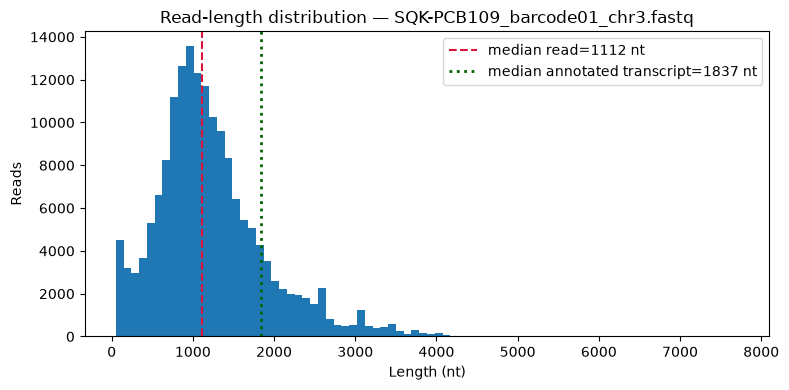

In [3]:
# ---- Read lengths from one FASTQ ----
# A FASTQ record is 4 lines: @id / sequence / + / quality. So every 4th line, starting from the
# second one, is a sequence -- that is what line_number % 4 == 1 picks out.
example_fq = fastq_path("barcode01")

read_lengths = []
for line_number, line in enumerate(open(example_fq)):
    if line_number % 4 == 1:                      # this line is a sequence
        read_lengths.append(len(line.strip()))
read_lengths = np.array(read_lengths)

print(f"{example_fq.name}: {len(read_lengths):,} reads | "
      f"mean {read_lengths.mean():.0f} nt | median {np.median(read_lengths):.0f} nt | "
      f"max {read_lengths.max():,} nt")

# ---- For scale: how long is an Arabidopsis transcript actually? ----
# Computed from the annotation we quantify against (AtRTDv2 chr3), so the number always matches
# this notebook's own reference. These are mature, spliced, polyadenylated transcript models --
# exon sequence only, no introns.
transcript_lengths = []
for record in open(TRANSCRIPTOME_FA).read().split(">")[1:]:
    header, sequence = record.split("\n", 1)     # drop the ">AT3G01040.1 ..." header line
    transcript_lengths.append(len(sequence.replace("\n", "")))
transcript_lengths = np.array(transcript_lengths)

median_read = np.median(read_lengths)
median_transcript = np.median(transcript_lengths)

print(f"AtRTDv2 chr3 poly(A)+ transcripts: {len(transcript_lengths):,} models | "
      f"mean {transcript_lengths.mean():.0f} nt | median {median_transcript:.0f} nt "
      f"(IQR {np.percentile(transcript_lengths, 25):.0f}–"
      f"{np.percentile(transcript_lengths, 75):.0f} nt)")

reads_at_least_median = (read_lengths >= median_transcript).mean()
print(f"  -> {reads_at_least_median:.0%} of reads are at least as long as the "
      f"median transcript; median read is {median_read/median_transcript:.0%} of it.")

plt.figure(figsize=(8, 4))
plt.hist(read_lengths, bins=80)
plt.axvline(median_read, color="crimson", ls="--",
            label=f"median read={median_read:.0f} nt")
plt.axvline(median_transcript, color="darkgreen", ls=":", lw=2,
            label=f"median annotated transcript={median_transcript:.0f} nt")
plt.xlabel("Length (nt)"); plt.ylabel("Reads")
plt.title(f"Read-length distribution — {example_fq.name}")
plt.legend(); plt.tight_layout(); plt.show()


## 2. Align every sample to the genome

Everything downstream starts from one **splice-aware genome alignment** per library, because that
single BAM does three jobs:

| Consumer | Why it needs the genome alignment |
|----------|-----------------------------------|
| **StringTie** (step 4) | An assembler infers exons and introns from where reads align and where they *skip* — that is exactly what a spliced alignment records. |
| **IGV** (step 9) | To see an intron you have to look at genomic coordinates. |
| **Read-level intron counting** (step 9) | An `N` in the CIGAR string *is* a splicing event, counted directly. |

Key options for full-length cDNA:

* `-ax splice` — splice-aware alignment, so a read crossing an intron is reported as two blocks
  joined by an `N` gap rather than being forced to align through the intron.
* `-uf` — force the transcript's forward strand. cDNA reads keep transcript orientation, so this
  tells minimap2 to look for canonical `GT..AG` donors/acceptors on that strand only, which sharpens
  junction placement.
* `-k14` — a shorter seed than the default, which improves sensitivity on error-prone RNA reads.

Note what is **not** here: we are not aligning to a transcriptome yet. We cannot — we have not built
one. That happens in step 5, once per route.

> This cell is the longest in the notebook — roughly **1.5 minutes** for all 6 samples, peaking near
> 2 GB of RAM. A good moment to start it running and talk over it.


In [4]:
t0 = time.time()

# ---- 1) Genome index (once) ----
# k=14 matches the -k14 we use for the spliced alignment; indexing is ~1 s and saves repeating the
# work across 6 runs.
run(f'"{MINIMAP2}" -k14 -d "{IDX_DIR}/genome.mmi" "{GENOME_FA}"')
print(f"Genome index built in {time.time()-t0:.0f}s")

# ---- 2) Splice-aware alignment, coordinate-sorted + indexed ----
# Coordinate-sorted is what StringTie and IGV both require.
t1 = time.time()
for cond, bc in SAMPLES:
    sid = sample_id(bc)
    gen_bam = BAM_GEN_DIR / f"{sid}.sorted.bam"
    run(f'"{MINIMAP2}" -t {THREADS} -ax splice -uf -k14 "{IDX_DIR}/genome.mmi" "{fastq_path(bc)}" '
        f'| "{SAMTOOLS}" sort -@ {THREADS} -o "{gen_bam}" -')
    run(f'"{SAMTOOLS}" index "{gen_bam}"')
    print(f"  ✓ {cond:9s} {bc}   ({time.time()-t1:.0f}s elapsed)")

print(f"\nAligned {len(SAMPLES)} samples to the genome in {time.time()-t1:.0f}s "
      f"({time.time()-t0:.0f}s including indexing)")


[M::mm_idx_gen::0.533*1.00] collected minimizers
[M::mm_idx_gen::0.664*1.39] sorted minimizers


[M::main::0.781*1.33] loaded/built the index for 1 target sequence(s)
[M::mm_idx_stat] kmer size: 14; skip: 10; is_hpc: 0; #seq: 1
[M::mm_idx_stat::0.811*1.32] distinct minimizers: 3349136 (82.79% are singletons); average occurrences: 1.303; average spacing: 5.375; total length: 23459830
[M::main] Version: 2.30-r1287
[M::main] CMD: <workshop>/tools/bin/minimap2 -k14 -d <workshop>/results/index/genome.mmi <workshop>/references/genome/TAIR10_chr3.fna
[M::main] Real time: 0.838 sec; CPU: 1.095 sec; Peak RSS: 0.248 GB


Genome index built in 1s


[WARNING] Indexing parameters (-k, -w or -H) overridden by parameters used in the prebuilt index.
[M::main::0.178*1.00] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::0.226*1.00] mid_occ = 31
[M::mm_idx_stat] kmer size: 14; skip: 10; is_hpc: 0; #seq: 1
[M::mm_idx_stat::0.256*1.00] distinct minimizers: 3349136 (82.79% are singletons); average occurrences: 1.303; average spacing: 5.375; total length: 23459830


[M::worker_pipeline::14.697*7.15] mapped 170160 sequences
[M::main] Version: 2.30-r1287
[M::main] CMD: <workshop>/tools/bin/minimap2 -t 8 -ax splice -uf -k14 <workshop>/results/index/genome.mmi <workshop>/data/fastq/SQK-PCB109_barcode01_chr3.fastq
[M::main] Real time: 14.711 sec; CPU: 105.148 sec; Peak RSS: 2.063 GB
[bam_sort_core] merging from 0 files and 8 in-memory blocks...


...

[M::worker_pipeline::7.430*6.95] mapped 111752 sequences
[M::main] Version: 2.30-r1287
[M::main] CMD: <workshop>/tools/bin/minimap2 -t 8 -ax splice -uf -k14 <workshop>/results/index/genome.mmi <workshop>/data/fastq/SQK-PCB109_barcode08_chr3.fastq
[M::main] Real time: 7.442 sec; CPU: 51.653 sec; Peak RSS: 1.252 GB
[bam_sort_core] merging from 0 files and 8 in-memory blocks...


  ✓ Cit_light barcode08   (53s elapsed)


[WARNING] Indexing parameters (-k, -w or -H) overridden by parameters used in the prebuilt index.
[M::main::0.181*1.00] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::0.227*1.00] mid_occ = 31
[M::mm_idx_stat] kmer size: 14; skip: 10; is_hpc: 0; #seq: 1
[M::mm_idx_stat::0.255*1.00] distinct minimizers: 3349136 (82.79% are singletons); average occurrences: 1.303; average spacing: 5.375; total length: 23459830


[M::worker_pipeline::7.484*6.88] mapped 107484 sequences
[M::main] Version: 2.30-r1287
[M::main] CMD: <workshop>/tools/bin/minimap2 -t 8 -ax splice -uf -k14 <workshop>/results/index/genome.mmi <workshop>/data/fastq/SQK-PCB109_barcode09_chr3.fastq
[M::main] Real time: 7.498 sec; CPU: 51.534 sec; Peak RSS: 1.069 GB
[bam_sort_core] merging from 0 files and 8 in-memory blocks...


  ✓ Cit_light barcode09   (62s elapsed)

Aligned 6 samples to the genome in 62s (63s including indexing)


## 3. Alignment QC

Before trusting anything downstream, check how many reads mapped. Full-length cDNA usually maps very
well; a low rate points at a wrong reference or a failed library.

Watch the **`total` column** as well as the percentage — one library is several-fold shallower than
its siblings. That is real data, and it matters more than usual today: **assembly is depth-sensitive
in a way that quantification is not.** A shallow library contributes fewer reads for StringTie to
build transcripts from, which is one reason we merge all six assemblies rather than assembling each
sample alone.


In [5]:
# samtools flagstat gives a text report per BAM; we pull two numbers out of each.
rows = []
for condition, barcode in SAMPLES:
    genome_bam = BAM_GEN_DIR / f"{sample_id(barcode)}.sorted.bam"
    report = shell_output(f'"{SAMTOOLS}" flagstat "{genome_bam}"')

    total  = int(re.search(r"(\d+) \+ \d+ in total", report).group(1))
    mapped = int(re.search(r"(\d+) \+ \d+ mapped \(", report).group(1))

    percent_mapped = round(100 * mapped / total, 1) if total else 0.0
    rows.append({"condition": condition, "barcode": barcode,
                 "total": total, "mapped": mapped, "mapped_%": percent_mapped})

qc = pd.DataFrame(rows)
display(qc)

deepest, shallowest = qc["total"].max(), qc["total"].min()
print("Mean mapping rate: {:.1f}%".format(qc["mapped_%"].mean()))
print("Depth range      : {:,} – {:,} alignment records "
      "({:.1f}× between the shallowest and deepest library)".format(
          shallowest, deepest, deepest / shallowest))


,condition,barcode,total,mapped,mapped_%
0,Nuc_light,barcode01,174670,171796,98.4
1,Nuc_light,barcode02,113395,112004,98.8
2,Nuc_light,barcode03,30431,29996,98.6
3,Cit_light,barcode07,183804,180578,98.2
4,Cit_light,barcode08,114175,111212,97.4
5,Cit_light,barcode09,110533,107467,97.2


Mean mapping rate: 98.1%
Depth range      : 30,431 – 183,804 alignment records (6.0× between the shallowest and deepest library)


## 4. Build a transcriptome from the reads — de novo assembly

Here is the problem this section exists to solve. Every tool we are about to use — the quantifier,
SUPPA2 — needs to be told **what transcripts exist**. For *Arabidopsis* somebody has already done
that work. For for most of the organisms, nobody has.

So we build the transcript set ourselves, from the spliced alignments we just made, using
**StringTie** in long-read mode. Three commands:

| Step | Command | What it does |
|------|---------|--------------|
| 1. Assemble per sample | `stringtie -L -p 8 -o st_<bc>.gtf <bam>` | Reconstruct transcripts from each library independently. `-L` is the long-read mode: it treats each read as (nearly) a full-length transcript rather than trying to stitch short fragments into a graph. |
| 2. Merge | `stringtie --merge -p 8 -o denovo.gtf st_*.gtf` | Unify the six per-sample assemblies into **one** non-redundant annotation, so all samples are quantified against the same transcript set. Without this, PSI values from different samples would not be comparable. |
| 3. Extract sequences | `gffread -w denovo.fa -g <genome> denovo.gtf` | Splice the exons out of the genome to produce transcript sequences — which is what `minimap2 -ax map-ont` and oarfish need. |

**Why assemble per sample and then merge?** The textbook answer — and the one the StringTie docs
give — is that StringTie's filters are all *relative* to local coverage (`-f 0.01` drops an isoform
below 1 % of its locus; `-j`/`-c` set coverage floors; `-t` trims on coverage). Judge each library
against its **own** depth and a transcript that is abundant in the nucleus survives on its own merits.
Pool everything first and that same transcript is scored as a fraction of nuclear **+** cytoplasmic
reads at the locus, so it can be diluted below threshold and dropped.

That is a real mechanism. Whether it dominates *on your data* is an empirical question — and since
assembly takes 10 seconds, it is one you can simply answer. See the discussion box below.

**Two things to watch for in the output.** The assembly will contain **more transcripts than genes**
by a wide margin — that is the isoform diversity we are after. And the identifiers will be
`MSTRG.*`: StringTie has no idea what these genes are called, because nothing told it. Naming them is
a separate job (BLAST against a related species, or protein-domain search).

---

### ⚑ Discuss: how should we pool and merge?

**The question.** We have 6 BAMs, 2 conditions × 3 replicates. There are three sensible ways to get
one transcript set out of them:

| Strategy | Commands |
|---|---|
| **A. Per sample, then merge** (what this notebook does) | 6 × `stringtie -L`, then `--merge` |
| **B. Per condition, then merge** | `samtools merge` × 2 → 2 × `stringtie -L` → `--merge` |
| **C. Pool everything, assemble once** | `samtools merge` × 1 → 1 × `stringtie -L`, no merge step |

Before reading on: **which do you expect to win, and by what criterion?** Write down a prediction.
The dilution argument above predicts A. Take a moment on it — the answer is not what the argument
implies, and the reason why is the actual lesson.

**Measured on these six libraries** (chr3; precision/sensitivity are splice junctions vs AtRTDv2,
strand-aware; all three cost 10–17 s end to end, so cost does not decide this):

| Strategy | tx | genes | iso/gene | precision | sensitivity | F1 | exact chain | **RI events** |
|---|---|---|---|---|---|---|---|---|
| A. per sample + merge | 8,210 | 5,406 | 1.52 | 53.9 % | 69.7 % | 60.8 % | 31.3 % | **884** |
| B. per condition + merge | 7,516 | 5,636 | 1.33 | 56.6 % | **70.5 %** | 62.8 % | 34.5 % | **550** |
| C. all 6 pooled | **9,569** | 5,749 | **1.66** | **58.8 %** | 69.7 % | **63.8 %** | **34.7 %** | **2,442** |

**Three things worth arguing about.**

1. **The dilution argument predicts A wins. It doesn't.** C is better on precision (+4.9 pts), F1,
   exact intron chains, transcript count *and* isoforms per gene. Why? These are six libraries of the
   same tissue in the same species at 30k–180k reads each, and long-read assembly is **starved of
   depth**. Pooling triples per-locus coverage, which buys more than the relative thresholds cost.
   Dilution bites when conditions are genuinely disjoint (different tissues, a knockout); nucleus and
   cytoplasm share most of their transcriptome.

2. **`--merge` unions transcripts — nothing vetoes a one-library artefact.** Of the junctions unique
   to strategy A, only **11.6 %** are corroborated by AtRTDv2; for C it is **27.6 %**. A spurious
   low-coverage isoform called in *one* replicate enters A's final annotation unopposed, because
   `--merge` operates on transcripts and never revisits the reads. That is the hidden cost of A.

3. **B looks like the sensible compromise and is the worst choice for *this* analysis.** It has the
   best sensitivity, but only **1.33 isoforms per gene** — and a retained-intron event needs *both*
   the spliced and the retained form present in the annotation. Fewer isoforms per gene → fewer
   testable events: **550 RI events vs 2,442 for C.** Averaging over replicates smoothed away exactly
   the isoform diversity the event analysis feeds on. Note what this means: *the metric you optimise
   has to be the one your biological question depends on.* B wins on sensitivity and loses the
   experiment.

**So why does this notebook still use A?** Two honest reasons. It is the community-standard idiom, so
it is what you will read in other people's methods sections and what generalises to designs where
pooling *does* hurt. And every downstream number in this notebook was computed with it. But on this
dataset it is **not** the best-scoring option, and you should know that before you copy the recipe.

**Try it.** `samtools merge -@ 8 pooled.bam <the 6 BAMs>` then `stringtie -L -p 8 -o pooled.gtf
pooled.bam` — about 15 seconds. Point `DENOVO_GTF` at the result, re-run from step 4, and see which
conclusions move and which do not. (The headline biology survives all three: the nucleus-retained
majority holds, and the demo intron `Chr3:462787-463031` is present in every one of them.)

**The transferable lesson.** "Best practice" is a claim about a *typical* dataset, not a theorem about
yours. Assembly here costs 10 seconds — cheap enough that you should test the recipe rather than
inherit it. When it costs 10 hours, that is when you rely on the convention.

---

> **Cost:** about **10 seconds** for all six samples, plus a fraction of a second to merge and
> extract. Assembly is not the expensive part of this pipeline — alignment is.

> **A note on the name, and on judging whether a tool is alive.** The `-L` long-read mode is what the
> **StringTie2** paper describes (Kovaka et al. 2019, *Genome Biology*) — that is the citation for the
> method. The *software* is a different question: run `stringtie --version` in the cell above and it
> reports **v3.0.3**, released November 2025, with upstream commits continuing into 2026.
> "StringTie2" is a paper title, not a version number.
>
> Worth generalising, because it will come up again with other tools: **"last paper" and "last commit"
> are different signals**, and for long-lived bioinformatics software they diverge by years. Judge
> maintenance from the release history, not the citation date. A genuinely abandoned tool looks
> different — no releases for years, and issues accumulating without replies.

> **Could we use something else?** Yes, and for real work you probably should try one:
> **FLAIR** (v3.0.0, Jan 2026) is ONT-native and does its own splice-site correction; **IsoQuant**
> is usually the accuracy leader in the LRGASP benchmark (Pardo-Palacios et al. 2024, *Nat Methods*),
> which included a "genome but no annotation" challenge — exactly our situation. The concordance code
> in step 8 would compare an alternative assembly against this one with no changes.
>
> StringTie is here for reasons of **workshop fit**, not quality: it is one command that finishes in
> 10 seconds (FLAIR is a three-stage pipeline; IsoQuant is much slower), it *only* assembles — so
> "which transcripts exist" stays visibly separate from "how much of each", which is oarfish's job —
> and it is a single static binary, which is why `tools/bin` works without conda at all.
>
> One option is genuinely closed to us. Assemblers like **RATTLE** need no genome whatsoever, which
> sounds like the ideal answer to "no reference". But they output transcript *sequences* with no
> genomic coordinates, and SUPPA2 defines events in genome coordinates — so they cannot feed this
> pipeline at all. Needing a genome is a constraint of the **event-level method**, not of StringTie.


In [6]:
t0 = time.time()

# ---- 1) Assemble each library independently, in long-read mode ----
per_sample_gtf = []
for condition, barcode in SAMPLES:
    out_gtf = ASM_DIR / f"st_{barcode}.gtf"
    genome_bam = BAM_GEN_DIR / f"{sample_id(barcode)}.sorted.bam"
    run(f'"{STRINGTIE}" -L -p {THREADS} -o "{out_gtf}" "{genome_bam}"')

    n_transcripts = 0
    for line in open(out_gtf):
        if not line.startswith("#") and line.split("\t")[2] == "transcript":
            n_transcripts += 1
    per_sample_gtf.append(out_gtf)
    print(f"  ✓ {condition:9s} {barcode}   {n_transcripts:>6,} transcripts assembled")

# ---- 2) Merge the six assemblies into one non-redundant annotation ----
gtf_arguments = " ".join(f'"{gtf}"' for gtf in per_sample_gtf)
run(f'"{STRINGTIE}" --merge -p {THREADS} -o "{DENOVO_GTF}" {gtf_arguments}')

# ---- 3) Splice transcript sequences out of the genome ----
run(f'"{GFFREAD}" -w "{DENOVO_FA}" -g "{GENOME_FA}" "{DENOVO_GTF}" 2> /dev/null')

# ---- What did we build? ----
# Count from the *exon* records, not "transcript" records. This is not pedantry: AtRTDv2 chr3
# contains ONLY exon lines -- no transcript feature at all -- so anything keyed on
# fields[2] == "transcript" silently reports zero for the reference. Exon records carry
# transcript_id/gene_id in both files, so counting from them is the one approach that works
# on either GTF.
def gtf_stats(gtf):
    """Return (number of transcripts, number of genes, number of exon records)."""
    transcripts, genes = set(), set()
    n_exons = 0
    for line in open(gtf):
        if line.startswith("#"):
            continue
        fields = line.split("\t")
        if len(fields) < 9 or fields[2] != "exon":
            continue
        n_exons += 1
        attributes = fields[8]
        transcript_match = re.search(r'transcript_id "([^"]+)"', attributes)
        gene_match       = re.search(r'gene_id "([^"]+)"', attributes)
        if transcript_match:
            transcripts.add(transcript_match.group(1))
        if gene_match:
            genes.add(gene_match.group(1))
    return len(transcripts), len(genes), n_exons

denovo_tx, denovo_genes, denovo_exons = gtf_stats(DENOVO_GTF)
ref_tx, ref_genes, ref_exons         = gtf_stats(ANNOTATION_GTF)
n_sequences = count_fasta_records(DENOVO_FA)

print(f"\nMerged assembly: {DENOVO_GTF.name}  ({time.time()-t0:.0f}s total)")
comparison = pd.DataFrame(
    {ROUTE_LABEL["denovo"]:    [denovo_tx, denovo_genes,
                                round(denovo_tx / denovo_genes, 2), denovo_exons],
     ROUTE_LABEL["reference"]: [ref_tx, ref_genes,
                                round(ref_tx / ref_genes, 2), ref_exons]},
    index=["transcripts", "genes", "isoforms per gene", "exon records"])
display(comparison)

assert n_sequences == denovo_tx, \
    f"gffread wrote {n_sequences} sequences for {denovo_tx} transcripts"
print(f"{n_sequences:,} transcript sequences written to {DENOVO_FA.name} "
      f"({DENOVO_FA.stat().st_size/1e6:.1f} MB) — this is the 'transcriptome' we quantify against.")

first_ids = re.findall(r'transcript_id "([^"]+)"', open(DENOVO_GTF).read()[:4000])
print("\nFirst assembled transcript ids: " + ", ".join(first_ids[:4])
      + "  <- no gene names, as promised.")


  ✓ Nuc_light barcode01    7,132 transcripts assembled


  ✓ Nuc_light barcode02    6,204 transcripts assembled


  ✓ Nuc_light barcode03    2,650 transcripts assembled


  ✓ Cit_light barcode07    4,513 transcripts assembled


  ✓ Cit_light barcode08    3,532 transcripts assembled


  ✓ Cit_light barcode09    3,282 transcripts assembled



Merged assembly: denovo.gtf  (12s total)


,de novo (StringTie),reference (AtRTDv2)
transcripts,8210.00,10524.0
genes,5406.00,4382.0
isoforms per gene,1.52,2.4
exon records,52227.00,77695.0


8,210 transcript sequences written to denovo.fa (15.2 MB) — this is the 'transcriptome' we quantify against.

First assembled transcript ids: MSTRG.1.1, MSTRG.1.1, MSTRG.1.1, MSTRG.1.1  <- no gene names, as promised.


### How good is that assembly?

We have a curated annotation for this organism, so we can grade our own homework. **In the field you
would not have this** — which is why it is worth doing once here, to calibrate how much to trust a de
novo splicing result in general.

The unit of comparison for splicing is the **splice junction** (one intron: chromosome, strand,
start, end):

* **Precision** — of the junctions we propose, what fraction is in AtRTDv2? Low = we invent introns.
* **Sensitivity** — of AtRTDv2's chr3 junctions, what fraction did we recover? Low = we miss real ones.
* **Exact intron chain** — the strict version: a transcript counts only if *every* one of its introns
  matches a reference transcript's, in order. (Endpoints are ignored, since where a read starts is an
  accident of sampling. Same definition `gffcompare` uses.)

**AtRTDv2 is clearly the better annotation, and the numbers below say so plainly.** Roughly half our
junctions are not in it and we miss a third of its own — a curated annotation pooling many
experiments beats a 6-library assembly, and you should expect that. Two reasons, briefly: missing
junctions are mostly **depth** (an isoform no read covered cannot be assembled), and extra junctions
are part real (nuclear RNA is rich in incompletely processed molecules AtRTDv2 under-represents) and
part noise (`stringtie -j` / `-c` trades one against the other).

The point of the de novo route is not that it wins. It is that **it works at all** — and for most
organisms it is the only option. Keep these numbers in mind: every de novo result below inherits them.
That is the price of not having a reference, and it is a price, not a disqualification.

Splice junctions   reference  24,103   de novo  31,140   shared  16,799
  Precision    53.9%   (14,341 junctions we propose that AtRTDv2 does not have)
  Sensitivity  69.7%   (7,304 annotated junctions we missed)

Exact intron chain  2,530 / 8,088 multi-exon transcripts (31.3%) match a reference transcript exactly
  (plus 122 single-exon transcripts, which have no junctions to check)


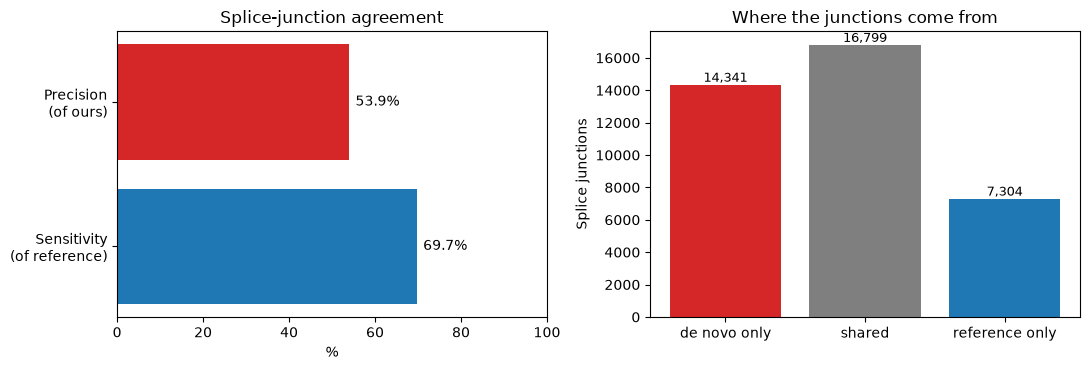

Keep these numbers in mind for the rest of the notebook: every de novo splicing result below
inherits them. This is the price of not having a reference — and it is a price, not a
disqualification.


In [7]:
def intron_chains(gtf):
    """For each transcript, the ordered list of its introns.

    Returns {transcript_id: ((chrom, strand, intron_start, intron_end), ...)}.

    A GTF lists exons, so the introns are the gaps between consecutive exons: an intron starts
    one base after an exon ends and stops one base before the next exon begins.

    A junction is keyed WITH its strand. That is deliberate and it is the stricter choice:
    StringTie sometimes assembles the same locus on both strands, and a strand-agnostic key
    would silently merge those into one "correct" junction and flatter our precision by
    several points.
    """
    exons_by_transcript = {}         # transcript_id -> list of (exon_start, exon_end)
    place_by_transcript = {}         # transcript_id -> (chrom, strand)

    for line in open(gtf):
        if line.startswith("#"):
            continue
        fields = line.rstrip("\n").split("\t")
        if len(fields) < 9 or fields[2] != "exon":
            continue
        match = re.search(r'transcript_id "([^"]+)"', fields[8])
        if not match:
            continue
        transcript_id = match.group(1)
        exons_by_transcript.setdefault(transcript_id, []).append((int(fields[3]), int(fields[4])))
        place_by_transcript[transcript_id] = (fields[0], fields[6])

    chains = {}
    for transcript_id, exons in exons_by_transcript.items():
        exons.sort()
        chrom, strand = place_by_transcript[transcript_id]
        introns = []
        for i in range(len(exons) - 1):
            this_exon_end   = exons[i][1]
            next_exon_start = exons[i + 1][0]
            introns.append((chrom, strand, this_exon_end + 1, next_exon_start - 1))
        chains[transcript_id] = tuple(introns)
    return chains

ref_chains    = intron_chains(ANNOTATION_GTF)
denovo_chains = intron_chains(DENOVO_GTF)

# Flatten both to a set of junctions, so we can ask how much they overlap.
ref_junctions, denovo_junctions = set(), set()
for chain in ref_chains.values():
    ref_junctions.update(chain)
for chain in denovo_chains.values():
    denovo_junctions.update(chain)

shared = denovo_junctions & ref_junctions
precision   = 100 * len(shared) / len(denovo_junctions)
sensitivity = 100 * len(shared) / len(ref_junctions)

# Exact intron chain: a transcript counts only if ALL of its introns match a reference
# transcript's, in the same order. Single-exon transcripts have no introns, so they are set aside.
reference_chain_set = set()
for chain in ref_chains.values():
    if chain:
        reference_chain_set.add(chain)

denovo_multi_exon = []
for chain in denovo_chains.values():
    if chain:
        denovo_multi_exon.append(chain)

exact_matches = 0
for chain in denovo_multi_exon:
    if chain in reference_chain_set:
        exact_matches += 1

n_single_exon = len(denovo_chains) - len(denovo_multi_exon)

print(f"Splice junctions   reference {len(ref_junctions):>7,}   "
      f"de novo {len(denovo_junctions):>7,}   shared {len(shared):>7,}")
print(f"  Precision   {precision:5.1f}%   "
      f"({len(denovo_junctions)-len(shared):,} junctions we propose that AtRTDv2 does not have)")
print(f"  Sensitivity {sensitivity:5.1f}%   "
      f"({len(ref_junctions)-len(shared):,} annotated junctions we missed)")
print(f"\nExact intron chain  {exact_matches:,} / {len(denovo_multi_exon):,} multi-exon "
      f"transcripts ({100*exact_matches/len(denovo_multi_exon):.1f}%) match a reference "
      f"transcript exactly")
print(f"  (plus {n_single_exon:,} single-exon transcripts, which have no junctions to check)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].barh(["Sensitivity\n(of reference)", "Precision\n(of ours)"], [sensitivity, precision],
           color=["#1f77b4", "#d62728"])
for i, value in enumerate([sensitivity, precision]):
    ax[0].text(value + 1.5, i, f"{value:.1f}%", va="center")
ax[0].set_xlim(0, 100); ax[0].set_xlabel("%"); ax[0].set_title("Splice-junction agreement")

only_denovo = len(denovo_junctions - ref_junctions)
only_ref    = len(ref_junctions - denovo_junctions)
bar_heights = [only_denovo, len(shared), only_ref]
ax[1].bar(["de novo only", "shared", "reference only"], bar_heights,
          color=["#d62728", "#7f7f7f", "#1f77b4"])
ax[1].set_ylabel("Splice junctions"); ax[1].set_title("Where the junctions come from")
for i, value in enumerate(bar_heights):
    ax[1].text(i, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()

print("Keep these numbers in mind for the rest of the notebook: every de novo splicing result below\n"
      "inherits them. This is the price of not having a reference — and it is a price, not a\n"
      "disqualification.")


## 5. Quantify with **oarfish** — against both transcript sets

Now we have two transcript FASTAs: **ours** and **AtRTDv2**. From here on, every step runs twice, in
a loop over `ROUTES`, with the annotation as the only thing that changes.

For each route we align the reads to *that* transcript set and quantify:

* `-ax map-ont` — align to transcript *sequences*. There are no introns to span, so no splice model.
* `--eqx -N 100` — two separate flags, both of them feeding the quantifier. Straight from
  `minimap2 --help`:
  * **`-N INT`** — *retain at most INT secondary alignments* (default **5**). A secondary alignment
    is an additional place the read fits. A read from a gene with 8 similar isoforms is genuinely
    compatible with several of them, and the quantifier can only weigh that ambiguity if the aligner
    reports it — at the default we would keep 5 candidates and silently discard the rest. It is a
    *cap*, not a quota: an unambiguous read still gets one alignment.
  * **`--eqx`** — *write `=`/`X` CIGAR operators* instead of a generic `M`. `M` means "aligned" and
    lumps matches together with mismatches, so `120M` does not tell you how many bases actually
    matched; `--eqx` gives you `45=1X74=`. The alignment itself is identical — only the bookkeeping
    is more explicit — but oarfish needs that resolution to *score* alignments, since it cannot
    otherwise distinguish a perfect 120-base match from one carrying 8 mismatches.

  The two reinforce each other: `-N 100` hands the quantifier more candidates, `--eqx` lets it rank
  them. Raising the cap without accurate scoring would only add noise. These are the flags the
  oarfish authors recommend for ONT data — and they matter *more* on our assembly than on the
  reference, because StringTie emits partially redundant transcripts that reads are legitimately
  ambiguous between.

### What the EM algorithm is doing

**oarfish** then runs an **EM (Expectation-Maximisation) algorithm** over the transcriptome BAM. It
is worth understanding, because it explains a result that otherwise looks like a bug.

The problem is circular. If you knew which isoform each read came from, counting would be trivial.
If you knew each isoform's abundance, assigning the reads would be trivial. You know **neither** —
and isoforms of one gene share most of their exons, so most reads are compatible with several of
them. EM breaks the circle by alternating:

1. **Guess** the abundances (start uniform).
2. **E-step** — split each read across its compatible transcripts *in proportion to* the current
   abundances. A read compatible with isoforms A and B, where A currently looks 3× more abundant,
   contributes **0.75 to A and 0.25 to B**. Fractional, not winner-take-all.
3. **M-step** — re-total those fractional contributions into new abundance estimates.
4. Repeat until nothing moves (`--max-em-iter 1000`, convergence threshold `0.001`).

Each round provably does not decrease the likelihood of the observed alignments, so it converges.

**This is why `num_reads` is often not a whole number** — it is a sum of fractions, and students
reliably find that startling until they have seen the E-step. In the reference route for barcode01,
3,523 transcripts carry a fractional count. `AT3G24160` is a clean example: four annotated isoforms,
275 reads between them, and the split is anything but obvious —

```
AT3G24160_P1     232.79      <- the EM concentrates most of the evidence here
AT3G24160_ID3     31.89
AT3G24160_ID1     10.31
AT3G24160_ID5      0.00      <- annotated, but no read prefers it
        sum =    275.000     <- fractional per isoform, whole at the gene
```

Note the arithmetic: the isoform estimates are fractional but the *gene* total comes out whole,
because every read is fully accounted for somewhere. An EM redistributes reads — it never invents or
loses them. Two honest caveats on using that as a check:

* The conservation law is exact at the **library** level: `num_reads` over all 10,524 transcripts sums
  to **169,552**, the number of aligned reads. Gene-level sums are whole only when a gene shares no
  reads with a neighbour. Here 171 of 4,382 loci break it — `AT3G55220` gets 31.52 reads and
  `AT3G55200` gets 22.48, which is a read the EM could not confidently assign to *either* overlapping
  gene. **They sum to exactly 54.** Nothing is lost; the unit of conservation is just larger than one
  gene.
* Compare with a tolerance, not `==`. Summing thousands of floats accumulates rounding, so
  `AT3G24160` is really `274.99999999999983`. Use `abs(s - round(s)) < 1e-6` (or `math.fsum`, which
  rounds exactly and does return 169552.0 for the library).

It is also why a transcript's estimate should never fall **below** its uniquely-mapped read count:
those reads have no ambiguity to redistribute. oarfish violated that bound 0/1344 times on one of
these libraries, salmon 1.11.4 violated it 86/1344 — the check in `REQUIREMENTS.md` §2 that decided
which quantifier this workshop uses.

Two flags shape the EM:

* `--model-coverage` — also model *where along the transcript* reads fall. A genuine full-length
  transcript should show coverage across its length; a spurious assignment often does not. (oarfish
  weights each alignment inside the E-step as `exp((score - best)/D)`, `D` default 5 — so a
  better-scoring alignment claims a larger share rather than all candidates counting equally. This
  is the term `--eqx` sharpens.)
* `--filter-group no-filters` — keep all alignments. The alternative, `nanocount-filters`, applies
  stricter NanoCount-style rules (a good exercise afterwards: rerun and compare).

Output is `<sample>.quant`, with columns *tname, len, num_reads*.

> **Why oarfish and not `salmon quant --ont`?** Because that flag no longer exists. salmon 2.x (the
> Rust rewrite, same lab) removed long-read mode and redirects you to oarfish.



In [8]:
t0 = time.time()
for route in ROUTES:
    transcript_fasta = ROUTE_FA[route]
    n_transcripts = count_fasta_records(transcript_fasta)
    print(f"--- {ROUTE_LABEL[route]}: {n_transcripts:,} transcript sequences ---")

    # Index this route's transcript FASTA (default k=15 is right for map-ont).
    route_index = IDX_DIR / f"{route}_tx.mmi"
    run(f'"{MINIMAP2}" -d "{route_index}" "{transcript_fasta}"')

    for condition, barcode in SAMPLES:
        transcriptome_bam = BAM_TX_DIR[route] / f"{sample_id(barcode)}.bam"
        quant_prefix      = OARFISH_DIR[route] / sample_id(barcode)

        # Transcriptome BAM for oarfish. minimap2's natural output order (grouped by read) is what
        # oarfish expects — do NOT coordinate-sort this one.
        run(f'"{MINIMAP2}" -t {THREADS} --eqx -N 100 -ax map-ont "{route_index}" '
            f'"{fastq_path(barcode)}" | "{SAMTOOLS}" view -@ 4 -b -o "{transcriptome_bam}" -')
        run(f'"{OARFISH}" -j {THREADS} -a "{transcriptome_bam}" -o "{quant_prefix}" '
            f'--filter-group no-filters --model-coverage > "{quant_prefix}.log" 2>&1')
        print(f"  ✓ {condition:9s} {barcode}   ({time.time()-t0:.0f}s elapsed)")

print(f"\nAligned + quantified {len(SAMPLES)} samples × {len(ROUTES)} routes "
      f"in {time.time()-t0:.0f}s")

# What oarfish gives us, for one sample on each route
for route in ROUTES:
    quant = pd.read_csv(OARFISH_DIR[route] / f"{sample_id('barcode01')}.quant", sep="\t")
    print(f"\n{ROUTE_LABEL[route]} — barcode01: {quant.shape[0]:,} transcripts quantified "
          f"| columns: {list(quant.columns)}")
    display(quant.sort_values("num_reads", ascending=False).head(3))


--- de novo (StringTie): 8,210 transcript sequences ---


[M::mm_idx_gen::0.319*1.01] collected minimizers
[M::mm_idx_gen::0.379*1.32] sorted minimizers
[M::main::0.452*1.27] loaded/built the index for 8210 target sequence(s)
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 8210
[M::mm_idx_stat::0.467*1.26] distinct minimizers: 1126648 (27.61% are singletons); average occurrences: 2.447; average spacing: 5.395; total length: 14875490
[M::main] Version: 2.30-r1287
[M::main] CMD: <workshop>/tools/bin/minimap2 -d <workshop>/results/index/denovo_tx.mmi <workshop>/results/stringtie/denovo.fa
[M::main] Real time: 0.487 sec; CPU: 0.609 sec; Peak RSS: 0.270 GB


[M::main::0.083*0.99] loaded/built the index for 8210 target sequence(s)
[M::mm_mapopt_update::0.102*0.99] mid_occ = 18
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 8210
[M::mm_idx_stat::0.114*0.99] distinct minimizers: 1126648 (27.61% are singletons); average occurrences: 2.447; average spacing: 5.395; total length: 14875490


[M::worker_pipeline::22.523*6.81] mapped 170160 sequences
[M::main] Version: 2.30-r1287
[M::main] CMD: <workshop>/tools/bin/minimap2 -t 8 --eqx -N 100 -ax map-ont <workshop>/results/index/denovo_tx.mmi <workshop>/data/fastq/SQK-PCB109_barcode01_chr3.fastq
[M::main] Real time: 22.544 sec; CPU: 153.506 sec; Peak RSS: 1.071 GB


  ✓ Nuc_light barcode01   (26s elapsed)


...

[M::worker_pipeline::8.177*6.63] mapped 107484 sequences
[M::main] Version: 2.30-r1287
[M::main] CMD: <workshop>/tools/bin/minimap2 -t 8 --eqx -N 100 -ax map-ont <workshop>/results/index/reference_tx.mmi <workshop>/data/fastq/SQK-PCB109_barcode09_chr3.fastq
[M::main] Real time: 8.185 sec; CPU: 54.248 sec; Peak RSS: 0.531 GB


  ✓ Cit_light barcode09   (170s elapsed)

Aligned + quantified 6 samples × 2 routes in 170s

de novo (StringTie) — barcode01: 8,210 transcripts quantified | columns: ['tname', 'len', 'num_reads']


,tname,len,num_reads
4989,MSTRG.3284.1,12138,24377.934292
4991,MSTRG.3284.3,6122,8729.543343
5492,MSTRG.3614.1,1756,1701.935235



reference (AtRTDv2) — barcode01: 10,524 transcripts quantified | columns: ['tname', 'len', 'num_reads']


,tname,len,num_reads
6289,AT3G41979_JS1,5021,24171.999996
6288,AT3G41768.1,1808,8986.000000
6974,AT3G47470.1,1266,1701.768248


### From read counts to TPM

oarfish reports **`num_reads`** (estimated reads per transcript) and no TPM column, so we normalise
ourselves: divide by the library total and scale to a million.

$$\text{TPM}_i = \frac{\text{num\_reads}_i}{\sum_j \text{num\_reads}_j} \times 10^6$$

**Why bother?** Because our libraries were not sequenced equally deeply — barcode03 has 29,719 reads
where barcode07 has 180,107, a 6-fold difference. Raw counts therefore say as much about sequencing
luck as about biology, and comparing them across samples would mostly measure depth. Dividing by each
library's own total removes that: TPM is a **share of the library**, so every sample is put on the
same scale and the numbers become comparable. One example from these very files:

```
AT3G53870_P1    barcode01:  359 reads = 2117 TPM
                barcode03:   63 reads = 2120 TPM     <- 5.7x fewer reads, same abundance
```

Same transcript, same biological abundance, wildly different counts — and TPM says so.

Two things to keep in mind. TPM is **relative**: a transcript's value can rise because it really went
up, or because something else went down. And short-read pipelines divide by an *effective length*
first, since a long transcript yields more fragments than a short one at equal concentration —
**for full-length long reads that correction largely goes away**, because one read ≈ one molecule.
That is a genuine advantage of the data type, not a shortcut we are taking.

Then we build one transcript × sample matrix per route and check that replicates still cluster by
compartment. Treat this as a **smoke test, not a ranking**: it confirms the assembly did not scramble
the biology, but it passes easily and cannot tell you which annotation is better. The numbers that
*do* compare them are the junction precision / sensitivity above.

de novo (StringTie)       8,210 transcripts | all-zero rows 2,016 | mean r within-condition 0.830 vs between 0.727 (separation +0.103)
reference (AtRTDv2)      10,524 transcripts | all-zero rows 1,858 | mean r within-condition 0.769 vs between 0.657 (separation +0.111)


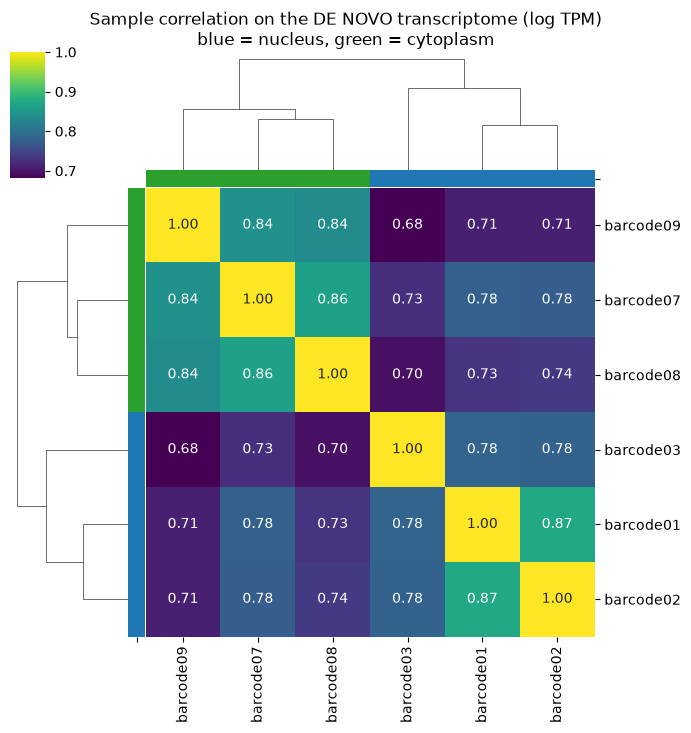

In [9]:
# ---- num_reads -> TPM, one matrix (transcripts × samples) per route ----
tpm = {}
for route in ROUTES:
    per_sample_tpm = []
    for condition, barcode in SAMPLES:
        quant = pd.read_csv(OARFISH_DIR[route] / f"{sample_id(barcode)}.quant", sep="\t",
                            usecols=["tname", "num_reads"]).set_index("tname")
        # TPM = this transcript's share of the library, scaled to a million.
        library_total = quant["num_reads"].sum()
        per_sample_tpm.append((quant["num_reads"] / library_total * 1e6).rename(barcode))
    tpm[route] = pd.concat(per_sample_tpm, axis=1)

# ---- Does the condition structure survive on each annotation? ----
# Compare replicate correlation WITHIN a condition against correlation BETWEEN conditions:
# within should clearly exceed between, or the compartments are not separating.
for route in ROUTES:
    matrix = tpm[route]
    correlation = np.log1p(matrix).corr()

    within_pairs = []
    for barcodes in CONDITIONS.values():
        for i, first in enumerate(barcodes):
            for second in barcodes[i+1:]:
                within_pairs.append(correlation.loc[first, second])

    between_pairs = []
    for nuclear in CONDITIONS[ORDER[0]]:
        for cytoplasmic in CONDITIONS[ORDER[1]]:
            between_pairs.append(correlation.loc[nuclear, cytoplasmic])

    mean_within, mean_between = np.mean(within_pairs), np.mean(between_pairs)
    all_zero_rows = int((matrix.sum(axis=1) == 0).sum())
    print(f"{ROUTE_LABEL[route]:24s} {matrix.shape[0]:>6,} transcripts | "
          f"all-zero rows {all_zero_rows:>5,} | "
          f"mean r within-condition {mean_within:.3f} vs between {mean_between:.3f} "
          f"(separation {mean_within - mean_between:+.3f})")

# ---- Show the clustermap for the de novo route — the one whose validity is in question ----
COND_COLOUR = {"Nuc_light": "#1f77b4", "Cit_light": "#2ca02c"}

sample_colours = {}
for condition, barcode in SAMPLES:
    sample_colours[barcode] = COND_COLOUR[condition]
sample_colours = pd.Series(sample_colours)

sns.clustermap(np.log1p(tpm["denovo"]).corr(), annot=True, fmt=".2f", cmap="viridis",
               col_colors=sample_colours, row_colors=sample_colours, figsize=(7, 7))
plt.suptitle("Sample correlation on the DE NOVO transcriptome (log TPM)\n"
             "blue = nucleus, green = cytoplasm", y=1.04)
plt.show()


## 6. Build per-condition expression matrices for SUPPA2

SUPPA2 reads **expression matrices** — transcripts × replicates, one file per condition — so we split
each route's TPM table by condition and write it out.

One detail that is easy to get wrong and painful to debug. SUPPA expects the header row to name
**only the samples**, leaving the index column *unlabelled*, so the header has one field fewer than
each data row:

```
        barcode01  barcode02  barcode03        <- 3 fields
AT3G01010_ID1   12.4   9.8   11.1              <- 4 fields
```

Add a `Name` label to that first column and `psiPerEvent` rejects every line
(`Unexpected number of fields. 5 expected, 4 given`) and then reports "No expression values have
been buffered" — which sounds like an empty-input problem rather than a header problem. Writing the
files ourselves from pandas keeps this explicit and correct.


In [10]:
for route in ROUTES:
    for condition, barcodes in CONDITIONS.items():
        out_file = TPM_DIR[route] / f"{condition}_TPM.tsv"
        with open(out_file, "w") as handle:
            # Sample names only — SUPPA wants the index column left unlabelled.
            handle.write("\t".join(barcodes) + "\n")
            tpm[route][barcodes].to_csv(handle, sep="\t", header=False, float_format="%.6f")
        print(f"  ✓ {route}/{out_file.name}  "
              f"({tpm[route].shape[0]:,} transcripts × {len(barcodes)} reps)")

# Verify the header convention holds: header must have exactly one field fewer than a data row.
for route in ROUTES:
    check_file = TPM_DIR[route] / f"{ORDER[0]}_TPM.tsv"
    with open(check_file) as handle:
        header_fields = len(next(handle).rstrip("\n").split("\t"))
        data_fields   = len(next(handle).rstrip("\n").split("\t"))
    if data_fields == header_fields + 1:
        verdict = "OK"
    else:
        verdict = "WRONG — SUPPA psiPerEvent will fail"
    print(f"\n{route}/{check_file.name}: header {header_fields} fields, "
          f"data rows {data_fields} fields -> {verdict}")


  ✓ denovo/Nuc_light_TPM.tsv  (8,210 transcripts × 3 reps)
  ✓ denovo/Cit_light_TPM.tsv  (8,210 transcripts × 3 reps)
  ✓ reference/Nuc_light_TPM.tsv  (10,524 transcripts × 3 reps)
  ✓ reference/Cit_light_TPM.tsv  (10,524 transcripts × 3 reps)

denovo/Nuc_light_TPM.tsv: header 3 fields, data rows 4 fields -> OK

reference/Nuc_light_TPM.tsv: header 3 fields, data rows 4 fields -> OK


## 7. SUPPA2 at the isoform level — *which isoform is used?*

**PSI** (Percent Spliced-In) is the workhorse quantity of splicing analysis: the fraction of a gene's
expression that a particular splicing choice accounts for, from 0 to 1. **ΔPSI** is its change
between conditions.

SUPPA2 can compute PSI two ways, and we do both because they answer different questions. First the
isoform level (`-f ioi`, *isoform inclusion*): PSI = the relative usage of one isoform within its
gene. Three commands, run once per route:

1. **`generateEvents -f ioi`** — parse the annotation into an isoform-inclusion file.
2. **`psiPerIsoform`** — turn each condition's TPM matrix into PSI per isoform per replicate.
3. **`diffSplice --method empirical`** — compare PSI between the two conditions, reporting ΔPSI and
   an empirical p-value. The p-value comes from the observed distribution of ΔPSI between replicates
   at comparable expression, which is more honest for small replicate numbers than a parametric test.
   `-gc` corrects p-values within genes.

Note that this step needs **only a GTF** — no transcript sequences, no reference genome annotation.
That is precisely why the de novo route can get here at all: StringTie hands us a GTF with
`gene_id`/`transcript_id`, and SUPPA does not care that the gene is called `MSTRG.1012` instead of
`AT3G02300`.


In [11]:
t0 = time.time()
IOI, ISO_CMP = {}, {}

for route in ROUTES:
    gtf = ROUTE_GTF[route]
    base = RUN / "SUPPA2" / route / f"{route}_isoforms"
    IOI[route]     = Path(str(base) + ".ioi")
    ISO_CMP[route] = CMP_DIR[route] / f"{COMPARISON}_isoform"

    # 1) Isoform-inclusion definitions from this route's annotation
    run(f'"{PY}" "{SUPPA}" generateEvents -i "{gtf}" -o "{base}" -f ioi')

    # 2) PSI per isoform, per condition.  NOTE: psiPerIsoform appends "_isoform.psi" to -o
    for condition in ORDER:
        run(f'"{PY}" "{SUPPA}" psiPerIsoform -g "{gtf}" '
            f'-e "{TPM_DIR[route]}/{condition}_TPM.tsv" -o "{PSI_DIR[route]}/{condition}"')

    # 3) Differential isoform usage between the two conditions
    psi_files = " ".join(f'"{PSI_DIR[route]}/{c}_isoform.psi"' for c in ORDER)
    tpm_files = " ".join(f'"{TPM_DIR[route]}/{c}_TPM.tsv"'     for c in ORDER)
    # diffSplice prints one progress line PER EVENT to stdout -- thousands of them. Send that to a
    # log file so the notebook stays readable; SUPPA's actual messages go to stderr and still show.
    run(f'"{PY}" "{SUPPA}" diffSplice --method empirical --input "{IOI[route]}" '
        f'--psi {psi_files} --tpm {tpm_files} '
        f'--area 1000 --lower-bound 0.05 -gc -o "{ISO_CMP[route]}" '
        f'> "{ISO_CMP[route]}.diffSplice.log"')

    n_isoforms = sum(1 for _ in open(IOI[route])) - 1      # minus the header line
    print(f"  ✓ {ROUTE_LABEL[route]:24s} {n_isoforms:,} isoforms")

print(f"\nIsoform-level analysis done for {len(ROUTES)} routes in {time.time()-t0:.0f}s")


INFO:eventGenerator:Reading input data.


INFO:eventGenerator:Done


INFO:psiPerGene:Reading GTF data.


INFO:psiPerGene:Reading Expression data.
INFO:psiPerGene:Calculating inclusion and generating output.


INFO:psiPerGene:Reading GTF data.


...

INFO:psiPerGene:Reading GTF data.


INFO:psiPerGene:Reading Expression data.
INFO:psiPerGene:Calculating inclusion and generating output.


INFO:psiPerGene:Reading GTF data.


INFO:psiPerGene:Reading Expression data.
INFO:psiPerGene:Calculating inclusion and generating output.


  ✓ reference (AtRTDv2)      10,524 isoforms

Isoform-level analysis done for 2 routes in 18s


### Reading the `.dpsi` table — and getting the sign right

The `.dpsi` file has one `_dPSI` and one `_p-val` column for our comparison. Before plotting anything
we have to be careful about **which direction ΔPSI points**, because SUPPA defines

$$\Delta\text{PSI} = \text{PSI}(\text{second condition}) - \text{PSI}(\text{first condition})$$

We passed `Nuc_light` first and `Cit_light` second, so SUPPA's column — despite being *named*
`Nuc_light-Cit_light` — actually holds **cytoplasm minus nucleus**. We flip it so that throughout the
rest of the notebook **positive ΔPSI = higher usage in the nucleus**, matching how we read the plots.

This is worth dwelling on for a second: a sign error here doesn't crash anything and doesn't look
wrong. It just silently inverts every biological conclusion you draw.


de novo (StringTie)       372 significant isoform-usage changes (|ΔPSI|≥0.1, p<0.05) out of 3,593 tested
reference (AtRTDv2)       390 significant isoform-usage changes (|ΔPSI|≥0.1, p<0.05) out of 8,167 tested


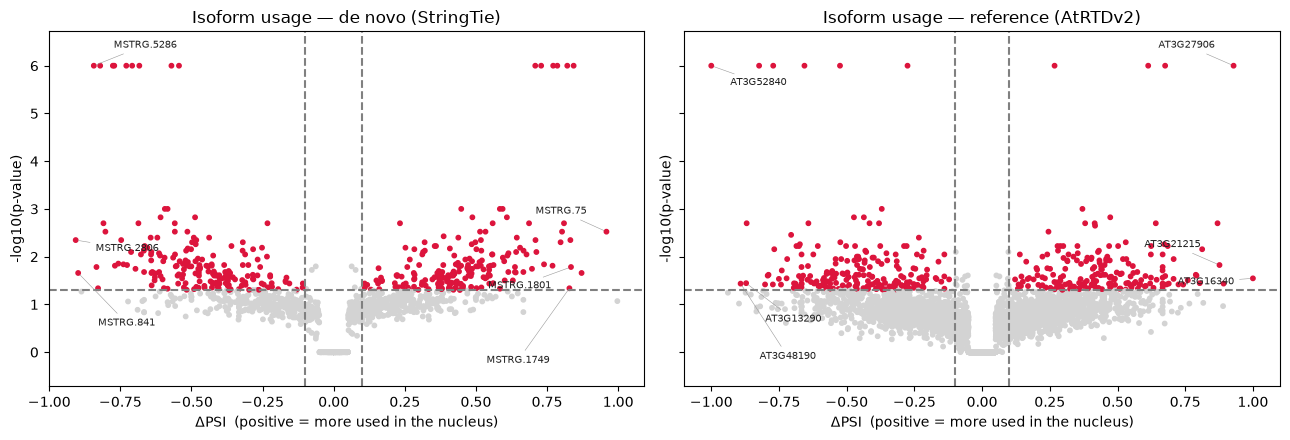


Top 10 isoform-usage changes — de novo (StringTie)


,dPSI,pval,significant
MSTRG.75;MSTRG.75.3,0.958684,0.002997,True
MSTRG.2806;MSTRG.2806.2,-0.907031,0.004496,True
MSTRG.841;MSTRG.841.4,-0.898375,0.021978,True
MSTRG.841;MSTRG.841.3,0.871260,0.021978,True
MSTRG.5286;MSTRG.5286.1,-0.843334,0.000000,True
MSTRG.5286;MSTRG.5286.2,0.843334,0.000000,True
MSTRG.1801;MSTRG.1801.1,0.834020,0.016484,True
MSTRG.1801;MSTRG.1801.2,-0.834020,0.016484,True
MSTRG.2806;MSTRG.2806.1,0.831916,0.004496,True
MSTRG.1749;MSTRG.1749.1,0.828481,0.045954,True



Top 10 isoform-usage changes — reference (AtRTDv2)


,dPSI,pval,significant
AT3G52840;AT3G52840_ID15,-1.000000,0.000000,True
AT3G16340;AT3G16340_P1,0.999989,0.028472,True
AT3G27906;AT3G27906_P1,0.928575,0.000000,True
AT3G48190;AT3G48190_P1,-0.891706,0.036713,True
AT3G48190;AT3G48190_P2,0.891706,0.036713,True
AT3G21215;AT3G21215_P1,0.876559,0.014985,True
AT3G13290;AT3G13290_JS1,-0.871233,0.035964,True
AT3G43300;AT3G43300_c1,-0.869345,0.001998,True
AT3G43300;AT3G43300_JS8,0.869345,0.001998,True
AT3G50670;AT3G50670_P1,-0.823358,0.000000,True


In [12]:
DPSI_CUT, P_CUT = 0.10, 0.05

def find_column(df, ending):
    """The one column whose name ends with `ending`. SUPPA names it after the comparison."""
    for name in df.columns:
        if name.endswith(ending):
            return name
    raise KeyError(f"no column ending in {ending!r}; found {list(df.columns)}")

def load_dpsi(prefix, flip=True):
    """Load a SUPPA .dpsi file into tidy dPSI/pval columns.

    SUPPA reports dPSI = PSI(second) - PSI(first). With ORDER = [Nuc, Cit] that means the raw
    column is Cit - Nuc, so we negate it: positive dPSI then means "higher in the nucleus".
    """
    df = pd.read_csv(Path(str(prefix) + ".dpsi"), sep="\t", index_col=0)
    result = df[[find_column(df, "_dPSI"), find_column(df, "_p-val")]].copy()
    result.columns = ["dPSI", "pval"]
    if flip:
        result["dPSI"] = -result["dPSI"]
    result = result.dropna()
    result["significant"] = (result["pval"] < P_CUT) & (result["dPSI"].abs() >= DPSI_CUT)
    return result

def by_effect_size(df):
    """Same rows, sorted with the largest |dPSI| first."""
    order = df["dPSI"].abs().sort_values(ascending=False).index
    return df.reindex(order)

def gene_of(row_name):
    """The gene part of a SUPPA row name.

    Both kinds of id start with the gene, then a semicolon:
        isoform level  AT3G01040;AT3G01040.1        -> AT3G01040
        event level    MSTRG.79;RI:Chr3:212746:...   -> MSTRG.79
    On the de novo route this is an MSTRG number, because an assembler has no gene names.
    """
    return row_name.split(";")[0]

def label_top_hits(ax, df, how_many=6):
    """Write the gene name next to the strongest significant points.

    One label per gene: a gene with three changed isoforms would otherwise use up three of our
    six labels to say the same name three times.
    """
    strongest = by_effect_size(df[df["significant"]])

    # Keep the biggest change per gene, in order, until we have `how_many` different genes.
    chosen, seen_genes = [], set()
    for row_name in strongest.index:
        gene = gene_of(row_name)
        if gene in seen_genes:
            continue
        seen_genes.add(gene)
        chosen.append(row_name)
        if len(chosen) == how_many:
            break

    # Where each dot is, tallest first.
    points = []
    for row_name in chosen:
        x = df.loc[row_name, "dPSI"]
        y = -np.log10(max(df.loc[row_name, "pval"], 1e-6))
        points.append((y, x, gene_of(row_name)))
    points.sort(reverse=True)

    # Labels sit to the side of their dot, pointing back towards the middle of the plot so they
    # stay on the canvas. Two labels at the same height would print on top of each other, so we
    # keep a minimum gap and push each label down until it clears the one above it.
    bottom, top = ax.get_ylim()
    min_gap = (top - bottom) * 0.105
    previous_label_y = None

    for y, x, gene in points:
        # Sit a little above the dot rather than level with it: many events share the p-value
        # ceiling, so a label at exactly the dot's height lands on a neighbouring point. Then keep
        # at least min_gap below the previous label, so a cluster of hits stacks instead of piling up.
        label_y = y + min_gap * 0.55
        if previous_label_y is not None:
            label_y = min(label_y, previous_label_y - min_gap)
        previous_label_y = label_y

        points_right = x >= 0
        label_x = x - 0.07 if points_right else x + 0.07
        ax.annotate(gene, xy=(x, y), xytext=(label_x, label_y), fontsize=7, va="center",
                    ha="right" if points_right else "left", color="#222222",
                    arrowprops=dict(arrowstyle="-", lw=0.4, color="#999999"))

def volcano(df, title, xlabel, ax=None, label_hits=True):
    if ax is None:
        ax = plt.subplots(figsize=(7, 5))[1]

    # Significant points in red, the rest in grey.
    colours = []
    for is_significant in df["significant"]:
        colours.append("crimson" if is_significant else "lightgray")

    ax.scatter(df["dPSI"], -np.log10(df["pval"].clip(lower=1e-6)), s=10, c=colours)
    for cut in (-DPSI_CUT, DPSI_CUT):
        ax.axvline(cut, ls="--", c="gray")
    ax.axhline(-np.log10(P_CUT), ls="--", c="gray")
    ax.set_xlabel(xlabel); ax.set_ylabel("-log10(p-value)"); ax.set_title(title)
    ax.margins(y=0.12)                     # headroom, so labels are not pressed against the frame

    if label_hits:
        label_top_hits(ax, df)
    return ax

isoform_results = {}
for route in ROUTES:
    isoform_results[route] = load_dpsi(ISO_CMP[route])

for route in ROUTES:
    result = isoform_results[route]
    n_significant = int(result["significant"].sum())
    print(f"{ROUTE_LABEL[route]:24s} {n_significant:>4d} significant isoform-usage "
          f"changes (|ΔPSI|≥{DPSI_CUT}, p<{P_CUT}) out of {len(result):,} tested")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for i, route in enumerate(ROUTES):
    volcano(isoform_results[route], f"Isoform usage — {ROUTE_LABEL[route]}",
            "ΔPSI  (positive = more used in the nucleus)", ax=axes[i])
plt.tight_layout(); plt.show()

# ---- The strongest hits on BOTH routes, side by side ----
# The labels above and the tables here carry the same contrast: AtRTDv2 gives you gene names you
# can look up, the assembly gives you MSTRG numbers. Naming those is a separate job (BLAST against
# a related species, or a protein-domain search). Note the MSTRG numbering changes every time the
# assembly is rebuilt, so read ids off your own run rather than copying them from a slide.
for route in ROUTES:
    result = isoform_results[route]
    top_hits = by_effect_size(result[result["significant"]]).head(10)
    print(f"\nTop 10 isoform-usage changes — {ROUTE_LABEL[route]}")
    display(top_hits)


## 8. SUPPA2 on local events — *which splicing decision changed?*

This is the heart of the module. Isoform-level PSI told us *that* a gene's isoform mix shifted;
**local events** tell us **what kind of splicing change** happened, which is what you actually want
to report and what a mechanism has to explain.

`generateEvents -f ioe` decomposes an annotation into seven classic event types:

| Code | Event | The decision being made |
|------|-------|-------------------------|
| **SE** | Skipped Exon | is this exon included or skipped? |
| **A3** | Alternative 3′ splice site | where does the downstream exon start? |
| **A5** | Alternative 5′ splice site | where does the upstream exon end? |
| **MX** | Mutually eXclusive exons | one exon or the other, never both |
| **RI** | **Retained Intron** | **is this intron removed at all?** |
| **AF** | Alternative First exon | which promoter / first exon? |
| **AL** | Alternative Last exon | which terminal exon / polyA site? |

Each event becomes an *inclusion vs. exclusion* contrast, so PSI has a concrete meaning: **the
fraction of that gene's molecules that took the inclusion path.** For an RI event, PSI is the
fraction of molecules that still contain the intron.

The pipeline mirrors the isoform one, with a different PSI command: `generateEvents -f ioe` →
**`psiPerEvent`** → `diffSplice`.

> Mind the naming asymmetry: `psiPerIsoform -o X` writes `X_isoform.psi`, but `psiPerEvent -o X`
> writes plain `X.psi`. Different code paths inside SUPPA.

### The biological question: what does a nucleus/cytoplasm split predict?

This is the part to think about before running anything. The cell does splicing and export in a
fixed order:

1. RNA polymerase II transcribes in the **nucleus**, and the spliceosome removes introns there —
   largely *co-transcriptionally*, while the transcript is still being made.
2. Only transcripts that finished processing are **exported** to the cytoplasm to be translated.
3. So at any instant the nucleus holds a mixture of finished and *unfinished* molecules, while the
   cytoplasm should hold almost only finished ones.

An unspliced intron is the signature of an unfinished molecule. The prediction is therefore sharp and
falsifiable: **retained introns should be enriched in the nuclear fraction and depleted in the
cytoplasm.** Not absent from the cytoplasm — some intron-containing transcripts do escape, and a few
are exported deliberately — but the bulk of the retention should sit on the nuclear side.

That prediction is worth stating out loud because it is a **known-answer control**. If the pipeline
returned retained introns spread evenly between the two fractions, or concentrated in the cytoplasm,
we would not have discovered surprising biology — we would have found a bug. Getting the expected
answer on a system where the answer is known is what licenses you to trust the same pipeline on a
question where it is not.

A second, subtler expectation: the *effect sizes* should be large. This is not a subtle
treatment-versus-control contrast where you hunt for a 5 % shift; it is two physically separated
compartments, so the introns that differ should differ a lot.

**And a prediction about the other six event classes:** they should barely move. SE, A3, A5 and MX are
choices *between two finished mRNAs* — both versions are spliced, both are exportable, so there is no
reason for the nucleus to prefer one. Only RI reports whether splicing has *happened at all*. So the
plot below should show one class standing apart from the rest, and it should be RI. That is a much
harder prediction to satisfy by accident than "RI differs".

The cell runs the events on **both** annotations, but keep the two comparisons straight: the biology is
**nucleus vs cytoplasm**, and the annotation is only a lens. The annotation-vs-annotation comparison is
in the **annex** at the end.


INFO:eventGenerator:Reading input data.


INFO:eventGenerator:Calculating events


INFO:eventGenerator:Done


  de novo (StringTie)      {'SE': 71, 'A3': 715, 'A5': 544, 'MX': 2, 'RI': 884, 'AF': 13, 'AL': 10}


INFO:eventGenerator:Reading input data.


...

INFO:lib.tools:File <workshop>/results/SUPPA2/reference/per_condition_TPM/Cit_light_TPM.tsv opened in reading mode.
INFO:psiCalculator:Buffering transcript expression levels.
INFO:lib.tools:File <workshop>/results/SUPPA2/reference/per_condition_TPM/Cit_light_TPM.tsv closed.
INFO:lib.tools:File <workshop>/results/SUPPA2/reference/events/events_MX_strict.ioe opened in reading mode.
INFO:psiCalculator:Calculating PSI from the ioe file.
INFO:lib.tools:File <workshop>/results/SUPPA2/reference/events/events_MX_strict.ioe closed.
INFO:psiCalculator:Generating output <workshop>/results/SUPPA2/reference/psi/Cit_light_MX.psi
INFO:psiCalculator:Done


  (skipping reference (AtRTDv2) MX: only 5 events measurable in both fractions)


INFO:lib.tools:File <workshop>/results/SUPPA2/reference/per_condition_TPM/Nuc_light_TPM.tsv opened in reading mode.
INFO:psiCalculator:Buffering transcript expression levels.
INFO:lib.tools:File <workshop>/results/SUPPA2/reference/per_condition_TPM/Nuc_light_TPM.tsv closed.
INFO:lib.tools:File <workshop>/results/SUPPA2/reference/events/events_RI_strict.ioe opened in reading mode.
INFO:psiCalculator:Calculating PSI from the ioe file.
INFO:lib.tools:File <workshop>/results/SUPPA2/reference/events/events_RI_strict.ioe closed.
INFO:psiCalculator:Generating output <workshop>/results/SUPPA2/reference/psi/Nuc_light_RI.psi
INFO:psiCalculator:Done


INFO:lib.tools:File <workshop>/results/SUPPA2/reference/per_condition_TPM/Cit_light_TPM.tsv opened in reading mode.
INFO:psiCalculator:Buffering transcript expression levels.
INFO:lib.tools:File <workshop>/results/SUPPA2/reference/per_condition_TPM/Cit_light_TPM.tsv closed.
INFO:lib.tools:File <workshop>/results/SUPPA2/reference/events/events_RI_strict.ioe opened in reading mode.
INFO:psiCalculator:Calculating PSI from the ioe file.
INFO:lib.tools:File <workshop>/results/SUPPA2/reference/events/events_RI_strict.ioe closed.
INFO:psiCalculator:Generating output <workshop>/results/SUPPA2/reference/psi/Cit_light_RI.psi
INFO:psiCalculator:Done


PSI for every event class, both fractions, both routes (29s)


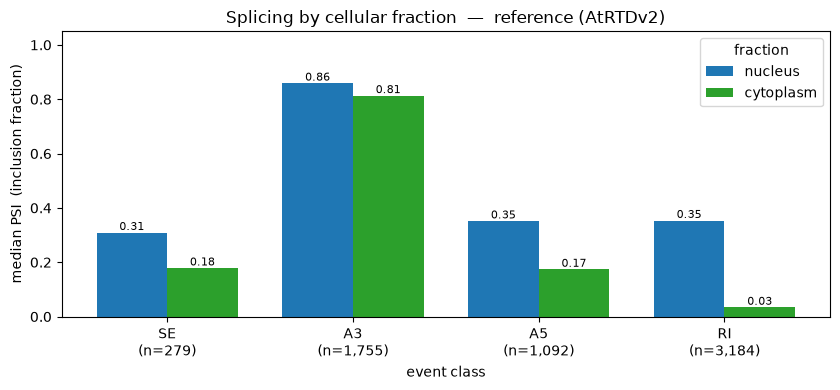

,nucleus,cytoplasm,identical in both (%),"% nuclear, of those that differ"
event class,,,,
SE,0.309,0.178,27.240,54.187
A3,0.859,0.813,26.838,58.411
A5,0.351,0.173,27.656,67.975
RI,0.353,0.034,16.363,80.360



The largest nucleus-to-cytoplasm difference is RI: 0.35 -> 0.03 (+0.32 PSI).
Every event class leans the same way — the nucleus always holds the less-processed
population — but retained introns are in a different league. An intron is either cut out
or it is not, so RI reads out completion directly; SE/A3/A5 are choices BETWEEN two
finished products, and both choices are exportable. That is why RI is the compartment
marker and the rest are only mildly shifted.

Read the last column as the direction check, and note it agrees: among events that differ
at all between the fractions, RI is ~80% nuclear while SE is barely past a coin flip.
This was predicted before the cell ran.

The de novo (StringTie) route sees the same thing for RI: 0.58 -> 0.23 over 687 events.


In [13]:
t0 = time.time()

# Decompose each annotation into local events.
#   -e takes generator names: SS produces A3 + A5, FL produces AF + AL.
EVENT_TYPES = ["SE", "A3", "A5", "MX", "RI", "AF", "AL"]
ioe_files = {}
counts    = {}

for route in ROUTES:
    run(f'"{PY}" "{SUPPA}" generateEvents -i "{ROUTE_GTF[route]}" '
        f'-o "{EVT_DIR[route]}/events" -f ioe -e SE SS MX RI FL')

    ioe_files[route], counts[route] = {}, {}
    for event_type in EVENT_TYPES:
        ioe = EVT_DIR[route] / f"events_{event_type}_strict.ioe"
        ioe_files[route][event_type] = ioe
        if ioe.is_file():
            counts[route][event_type] = sum(1 for _ in open(ioe)) - 1   # minus the header
        else:
            counts[route][event_type] = 0
    print(f"  {ROUTE_LABEL[route]:24s} {counts[route]}")
print(f"({time.time()-t0:.1f}s)")

# ---- PSI per event, per fraction, for every event class -------------------------------
# This is the measurement the biological question needs: for each kind of splicing decision,
# how does the nucleus differ from the cytoplasm?  (~30 s; the next cell reuses these .psi files.)
t0 = time.time()
MIN_EVENTS = 10                      # below this a median is not worth plotting

psi_rows = []                        # one row per (route, event class) — tidied into a table below
n_shared = {}                        # how many events were measurable in both fractions

for route in ROUTES:
    n_shared[route] = {}
    for event_type in EVENT_TYPES:
        if counts[route][event_type] == 0:
            continue

        for condition in ORDER:
            run(f'"{PY}" "{SUPPA}" psiPerEvent -i "{ioe_files[route][event_type]}" '
                f'-e "{TPM_DIR[route]}/{condition}_TPM.tsv" '
                f'-o "{PSI_DIR[route]}/{condition}_{event_type}"')

        # Mean PSI per event across the 3 replicates, one column per fraction.
        nucleus_psi   = pd.read_csv(PSI_DIR[route] / f"{ORDER[0]}_{event_type}.psi",
                                    sep="\t", index_col=0).mean(axis=1)
        cytoplasm_psi = pd.read_csv(PSI_DIR[route] / f"{ORDER[1]}_{event_type}.psi",
                                    sep="\t", index_col=0).mean(axis=1)
        both = pd.concat([nucleus_psi.rename("nucleus"),
                          cytoplasm_psi.rename("cytoplasm")], axis=1).dropna()

        if len(both) < MIN_EVENTS:
            print(f"  (skipping {ROUTE_LABEL[route]} {event_type}: only {len(both)} events "
                  f"measurable in both fractions)")
            continue

        # Many events have IDENTICAL PSI in both fractions (~27% here) -- fully spliced in both,
        # nothing to see. Counting those as "not higher in the nucleus" would understate the
        # asymmetry, so the directional column is computed over the events that actually DIFFER.
        differs = both[both["nucleus"] != both["cytoplasm"]]
        percent_identical = 100 * (1 - len(differs) / len(both))
        percent_nuclear   = 100 * (differs["nucleus"] > differs["cytoplasm"]).mean()

        n_shared[route][event_type] = len(both)
        psi_rows.append({"route": route, "event class": event_type,
                         "nucleus": both["nucleus"].median(),
                         "cytoplasm": both["cytoplasm"].median(),
                         "identical in both (%)": percent_identical,
                         "% nuclear, of those that differ": percent_nuclear})

psi_table = pd.DataFrame(psi_rows).set_index(["route", "event class"])
print(f"PSI for every event class, both fractions, both routes ({time.time()-t0:.0f}s)")

# ---- The plot: nucleus vs cytoplasm, one pair of bars per kind of splicing decision ----
MAIN = "reference" if "reference" in ROUTES else ROUTES[0]
main_table = psi_table.loc[MAIN]
plotted_types = [e for e in EVENT_TYPES if e in main_table.index]

x = np.arange(len(plotted_types))
bar_width = 0.38

plt.figure(figsize=(8.5, 4))
for i, condition in enumerate(ORDER):
    column = "nucleus" if condition == ORDER[0] else "cytoplasm"
    heights = [main_table.loc[e, column] for e in plotted_types]
    bars = plt.bar(x + (i - 0.5) * bar_width, heights, bar_width,
                   label=column, color=COND_COLOUR[condition])
    plt.bar_label(bars, fmt="%.2f", fontsize=8)

plt.xticks(x, [f"{e}\n(n={n_shared[MAIN][e]:,})" for e in plotted_types])
plt.ylabel("median PSI  (inclusion fraction)"); plt.ylim(0, 1.05)
plt.xlabel("event class")
plt.title(f"Splicing by cellular fraction  —  {ROUTE_LABEL[MAIN]}")
plt.legend(title="fraction"); plt.tight_layout(); plt.show()

display(main_table.round(3))

# Which class shows the biggest nucleus-to-cytoplasm drop?
drops = {}
for event_type in plotted_types:
    drops[event_type] = (main_table.loc[event_type, "nucleus"]
                         - main_table.loc[event_type, "cytoplasm"])
biggest = max(drops, key=drops.get)

print(f"\nThe largest nucleus-to-cytoplasm difference is {biggest}: "
      f"{main_table.loc[biggest, 'nucleus']:.2f} -> "
      f"{main_table.loc[biggest, 'cytoplasm']:.2f} ({drops[biggest]:+.2f} PSI).")
print("Every event class leans the same way — the nucleus always holds the less-processed\n"
      "population — but retained introns are in a different league. An intron is either cut out\n"
      "or it is not, so RI reads out completion directly; SE/A3/A5 are choices BETWEEN two\n"
      "finished products, and both choices are exportable. That is why RI is the compartment\n"
      "marker and the rest are only mildly shifted.\n")
print("Read the last column as the direction check, and note it agrees: among events that differ\n"
      "at all between the fractions, RI is ~80% nuclear while SE is barely past a coin flip.\n"
      "This was predicted before the cell ran.\n")

for route in ROUTES:
    if route == MAIN or "RI" not in psi_table.loc[route].index:
        continue
    ri = psi_table.loc[(route, "RI")]
    print(f"The {ROUTE_LABEL[route]} route sees the same thing for RI: "
          f"{ri['nucleus']:.2f} -> {ri['cytoplasm']:.2f} over {n_shared[route]['RI']:,} events.")


Differential intron retention, both routes, in 4s



,annotated RI,testable,significant,nucleus-retained,cytoplasm-retained,% nucleus
route,,,,,,
de novo (StringTie),884,399,70,63,7,90.0
reference (AtRTDv2),3526,2112,250,244,6,97.6


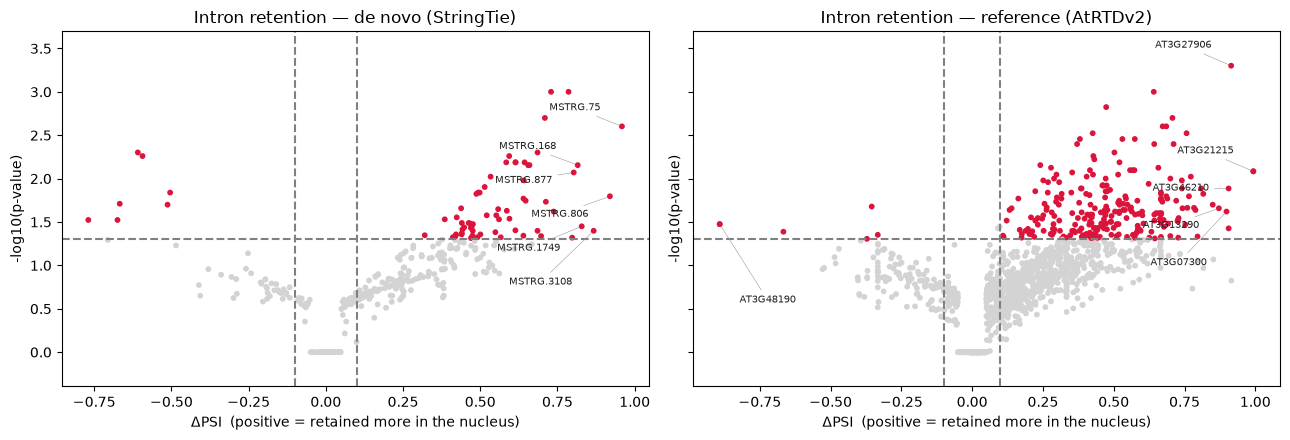


The plot in the cell above showed HOW MUCH intron is left in each fraction. This table
asks the other question: of the introns whose retention CHANGES significantly, which way
do they go? Nearly all of them are retained MORE in the nucleus. Noise would scatter them
evenly.


,dPSI,pval,significant
MSTRG.75;RI:Chr3:212746:213209-213311:213621:+,0.958684,0.002498,True
MSTRG.806;RI:Chr3:2326091:2326220-2326719:2327012:-,0.919721,0.015984,True
MSTRG.3108;RI:Chr3:10346058:10346441-10346704:10347381:-,0.867180,0.039960,True
MSTRG.1749;RI:Chr3:5200640:5200754-5201003:5201083:-,0.828481,0.035465,True
MSTRG.168;RI:Chr3:462615:462786-463032:463463:+,0.815522,0.006993,True
MSTRG.877;RI:Chr3:2508558:2508673-2509156:2509513:+,0.802605,0.008492,True
MSTRG.4627;RI:Chr3:20827144:20827510-20827621:20827952:-,0.797473,0.047952,True
MSTRG.1036;RI:Chr3:2986127:2987021-2987843:2987973:+,0.785766,0.000999,True
MSTRG.3586;RI:Chr3:17305284:17305464-17305550:17305723:+,-0.769152,0.029970,True
MSTRG.2123;RI:Chr3:6353271:6353336-6353502:6353554:+,0.737750,0.023976,True


In [14]:
# Focus on retained introns — the dominant class, and the one our biology predicts.
EVENT = "RI"
ri_results, EVT_CMP = {}, {}
t0 = time.time()

for route in ROUTES:
    ioe = ioe_files[route][EVENT]
    EVT_CMP[route] = CMP_DIR[route] / f"{COMPARISON}_{EVENT}"

    # PSI was already computed for every event class in the cell above.
    #   NOTE: psiPerEvent -o X writes X.psi (no "_isoform" suffix)
    psi_files = " ".join(f'"{PSI_DIR[route]}/{c}_{EVENT}.psi"' for c in ORDER)
    tpm_files = " ".join(f'"{TPM_DIR[route]}/{c}_TPM.tsv"'     for c in ORDER)
    run(f'"{PY}" "{SUPPA}" diffSplice --method empirical --input "{ioe}" '
        f'--psi {psi_files} --tpm {tpm_files} --area 1000 --lower-bound 0.05 -gc '
        f'-o "{EVT_CMP[route]}" > "{EVT_CMP[route]}.diffSplice.log"')

    ri_results[route] = load_dpsi(EVT_CMP[route])   # positive = retained more in the nucleus

print(f"Differential intron retention, both routes, in {time.time()-t0:.0f}s\n")

summary = []
for route in ROUTES:
    result = ri_results[route]
    significant = result[result["significant"]]
    nuclear     = int((significant["dPSI"] > 0).sum())
    cytoplasmic = int((significant["dPSI"] < 0).sum())
    if len(significant):
        percent_nuclear = round(100 * nuclear / len(significant), 1)
    else:
        percent_nuclear = np.nan
    summary.append({"route": ROUTE_LABEL[route],
                    "annotated RI": counts[route]["RI"],
                    "testable": len(result), "significant": len(significant),
                    "nucleus-retained": nuclear, "cytoplasm-retained": cytoplasmic,
                    "% nucleus": percent_nuclear})
display(pd.DataFrame(summary).set_index("route"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for i, route in enumerate(ROUTES):
    volcano(ri_results[route], f"Intron retention — {ROUTE_LABEL[route]}",
            "ΔPSI  (positive = retained more in the nucleus)", ax=axes[i])
plt.tight_layout(); plt.show()

print("\nThe plot in the cell above showed HOW MUCH intron is left in each fraction. This table\n"
      "asks the other question: of the introns whose retention CHANGES significantly, which way\n"
      "do they go? Nearly all of them are retained MORE in the nucleus. Noise would scatter them\n"
      "evenly.")

# The de novo hits, strongest first — these are the candidates the IGV step picks from.
top_events = by_effect_size(ri_results["denovo"][ri_results["denovo"]["significant"]])
display(top_events.head(10))


### Do the two routes agree on the *same introns*?

The table above compares the routes in aggregate. But aggregate agreement is weak evidence — two
analyses can produce similar-looking counts while pointing at completely different loci. The real
question is whether the de novo route finds **the same specific splicing events**.

Comparing them takes one careful step. A SUPPA event id encodes the flanking exon boundaries as well
as the intron, and those boundaries legitimately differ between an assembly and a curated
annotation — a truncated read gives a shorter first exon around the *same* intron. So we key each
event on **the intron itself** (chrom, start, end, strand) and ignore the flanks. Matching on the full
event id instead would undercount agreement for a purely cosmetic reason.

Then there is a second trap, and it is the more important one: **most de novo events cannot be
compared at all**, because the corresponding intron is not in AtRTDv2 or was not testable there. If
you divide your de novo hits by *all* of them, you are counting "the reference had no opinion" as
"the reference disagreed". Those are very different things. So the number to report is the
concordance among events **both** routes could actually test.


Introns testable on both routes: 150 (de novo 399, reference 2,103)

De novo significant introns                      : 70
  ...of which the reference could test at all     : 37
  ...of which the reference ALSO calls significant: 27

  -> concordance where comparison is possible: 73%  (27/37)
  -> the naive figure, dividing by all de novo hits, would be 39% — which counts 'the reference had no opinion' as 'the reference disagreed'.

On the 150 introns both routes tested: Pearson r 0.716, Spearman 0.700, and 89% point the SAME WAY.


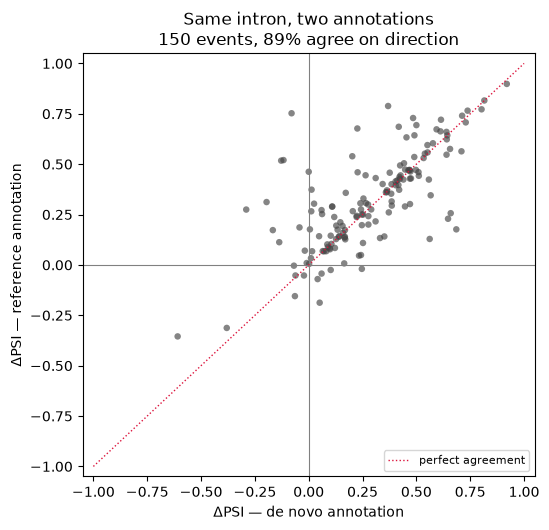

Points in the upper-right and lower-left quadrants are events the two annotations agree on.
This is the plot to remember: the annotation changes WHICH events you can see, far more than
it changes WHAT you conclude about the ones you can.


In [15]:
# A SUPPA RI event id encodes the flanking exons as well as the intron. We need both pieces here
# and again in the IGV section, so parse it once, properly.
def parse_ri(event_id):
    """<gene>;RI:Chr3:462615:462786-463032:463463:+  ->  the coordinates it encodes.

    Format is gene;RI:chrom:<exon1 start>:<exon1 end>-<exon2 start>:<exon2 end>:strand, so the
    retained intron is (exon1_end + 1) .. (exon2_start - 1). The gene id is whatever the
    annotation calls it -- AT3G02300 for AtRTDv2, an MSTRG number for our assembly.
    """
    gene, coordinates = event_id.split(";RI:")
    chrom, exon1_start, middle, exon2_end, strand = coordinates.split(":")
    exon1_end, exon2_start = middle.split("-")
    return dict(gene=gene, chrom=chrom, strand=strand,
                start=int(exon1_start), end=int(exon2_end),
                intron=(int(exon1_end) + 1, int(exon2_start) - 1))

# Key each RI event on the intron itself, discarding the flanking exon coordinates that a SUPPA
# event id also carries -- an assembly and a curated annotation legitimately disagree about exon
# ends while describing the very same intron.
def intron_key(event_id):
    event = parse_ri(event_id)
    return (event["chrom"], event["intron"][0], event["intron"][1], event["strand"])

# Add that key as a column on both routes' results.
keyed = {}
for route in ROUTES:
    result = ri_results[route].copy()
    result["intron"] = [intron_key(event_id) for event_id in result.index]
    keyed[route] = result

denovo, reference = keyed["denovo"], keyed["reference"]

denovo_testable    = set(denovo["intron"])
reference_testable = set(reference["intron"])
denovo_significant    = set(denovo[denovo["significant"]]["intron"])
reference_significant = set(reference[reference["significant"]]["intron"])

comparable = denovo_significant & reference_testable   # hits the reference could weigh in on
agreed     = denovo_significant & reference_significant

print(f"Introns testable on both routes: {len(denovo_testable & reference_testable):,} "
      f"(de novo {len(denovo_testable):,}, reference {len(reference_testable):,})\n")
print(f"De novo significant introns                      : {len(denovo_significant)}")
print(f"  ...of which the reference could test at all     : {len(comparable)}")
print(f"  ...of which the reference ALSO calls significant: {len(agreed)}")
print(f"\n  -> concordance where comparison is possible: "
      f"{100*len(agreed)/len(comparable):.0f}%  ({len(agreed)}/{len(comparable)})")
print(f"  -> the naive figure, dividing by all de novo hits, would be "
      f"{100*len(agreed)/len(denovo_significant):.0f}% — which counts 'the reference had no "
      f"opinion' as 'the reference disagreed'.")

# ---- Do the effect SIZES agree on the introns both routes tested? ----
# One dPSI per intron per route (a few introns appear in more than one event id, so average),
# then keep the introns present on both.
denovo_dpsi    = denovo.groupby("intron")["dPSI"].mean().rename("denovo")
reference_dpsi = reference.groupby("intron")["dPSI"].mean().rename("reference")
both = pd.concat([denovo_dpsi, reference_dpsi], axis=1, join="inner").dropna()

same_direction = 100 * (np.sign(both["denovo"]) == np.sign(both["reference"])).mean()
pearson  = both["denovo"].corr(both["reference"])
spearman = both["denovo"].corr(both["reference"], method="spearman")

print(f"\nOn the {len(both):,} introns both routes tested: Pearson r {pearson:.3f}, "
      f"Spearman {spearman:.3f}, and {same_direction:.0f}% point the SAME WAY.")

fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.axhline(0, c="gray", lw=0.8); ax.axvline(0, c="gray", lw=0.8)
ax.plot([-1, 1], [-1, 1], ls=":", c="crimson", lw=1, label="perfect agreement")
ax.scatter(both["denovo"], both["reference"], s=22, alpha=0.65, edgecolor="none", color="#444444")
ax.set_xlabel("ΔPSI — de novo annotation"); ax.set_ylabel("ΔPSI — reference annotation")
ax.set_title(f"Same intron, two annotations\n"
             f"{len(both):,} events, {same_direction:.0f}% agree on direction")
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

print("Points in the upper-right and lower-left quadrants are events the two annotations agree on.\n"
      "This is the plot to remember: the annotation changes WHICH events you can see, far more than\n"
      "it changes WHAT you conclude about the ones you can.")


## 9. Look at the reads — in IGV

Everything so far has been a **model's estimate** on top of an **assembled annotation** — two layers
of inference. PSI came out of an EM quantifier working on transcript-level abundances; it never
counted a single intron directly. So let's check it against the molecules.

The cell below counts, straight from the genome BAMs, how many reads at each de novo-called intron
were spliced and how many kept the intron — then picks the event with the strongest read-level
contrast. The next cell writes an IGV session for that locus so you can look at the reads yourself.

**Why this is the right check for a de novo analysis.** The read counting uses only the CIGAR strings
in the genome BAMs. It does not consult *any* annotation, de novo or reference. So it is an
**independent referee**: if StringTie invented an intron that is not really there, the reads will say
so. With full-length ONT reads each row is one cDNA molecule, and you can see with your own eyes
whether the intron is present.

**What to look for.** A spliced read is drawn with a thin line spanning the intron (a gap); an
intron-retaining read is drawn as continuous solid alignment straight through it. At a strong locus
the two tracks look qualitatively different: the nuclear track carries a large fraction of solid,
intron-containing reads, while the cytoplasmic track is close to uniformly spliced. Notice too that
the cytoplasmic track is usually **thinner** — a transcript that still has its intron never gets
exported, so it is not there to sequence. The low coverage is part of the signal, not a bad library.

We load **both annotation tracks**, assembled and curated, so you can compare the model StringTie
built from these reads against the curated model — at a locus where the reads adjudicate.


In [16]:
# ---------------------------------------------------------------------------------------------
# Count spliced vs. intron-retaining reads straight from the genome BAMs.
#
# This is an ANNOTATION-FREE check. SUPPA's PSI came out of transcript-level quantification on an
# assembled annotation; here we only look at reads. A read that spans the intron either has an N
# (skip) in its CIGAR -- it was spliced -- or aligns continuously through it -- the intron is there.
#
# Only reads that span the whole intron count. A read ending inside the intron tells us nothing
# about whether it would have been spliced, and counting those inflates apparent retention.
# ---------------------------------------------------------------------------------------------
# parse_ri() was defined in the concordance cell above; we reuse it here.
def intron_reads(chrom, intron_start, intron_end, barcode):
    """Return (spliced, retained) counts among reads spanning intron chrom:start-end."""
    intron_length = intron_end - intron_start + 1
    spliced = retained = 0

    genome_bam = BAM_GEN_DIR / f"{sample_id(barcode)}.sorted.bam"
    sam = shell_output(f'"{SAMTOOLS}" view "{genome_bam}" '
                       f'"{chrom}:{intron_start}-{intron_end}"')

    for line in sam.splitlines():
        fields = line.split("\t")
        flag = int(fields[1])
        if flag & 0x900:            # SAM flags 0x100 + 0x800: secondary / supplementary — skip
            continue

        position, cigar = int(fields[3]), fields[5]
        reference_position = position
        skipped = covered = 0       # bases of the intron the read skips vs. aligns through

        for length, operation in re.findall(r"(\d+)([MIDNSHP=X])", cigar):
            length = int(length)
            if operation not in "M=XDN":
                continue            # insertions/clips consume read, not reference
            # How much of this CIGAR block falls inside the intron?
            overlap_start = max(intron_start, reference_position)
            overlap_end   = min(intron_end, reference_position + length - 1)
            if overlap_end >= overlap_start:
                overlap = overlap_end - overlap_start + 1
                if operation == "N":
                    skipped += overlap
                else:
                    covered += overlap
            reference_position += length

        read_spans_intron = position <= intron_start and reference_position >= intron_end
        if read_spans_intron:
            if skipped >= 0.8 * intron_length:
                spliced += 1
            elif covered >= 0.8 * intron_length:
                retained += 1

    return spliced, retained

# ---- Choose the event to display: strongest read-level contrast among the DE NOVO calls ----
# We deliberately take the candidates from the de novo route, so what we put on screen is a locus
# our own assembly found. Nothing is hard-coded: the reads pick the winner.
MIN_READS = 10                                # per condition; fewer is not worth showing a class

nucleus_candidates = top_events[top_events["dPSI"] > 0].index[:20]
rows = []
for event_id in nucleus_candidates:
    event = parse_ri(event_id)
    intron_start, intron_end = event["intron"]

    # Pool the three replicates of each condition.
    totals = {}
    for condition, barcodes in CONDITIONS.items():
        spliced = retained = 0
        for barcode in barcodes:
            s, r = intron_reads(event["chrom"], intron_start, intron_end, barcode)
            spliced += s
            retained += r
        totals[condition] = (spliced, retained, spliced + retained)

    nuc_spliced, nuc_retained, nuc_total = totals[ORDER[0]]
    cit_spliced, cit_retained, cit_total = totals[ORDER[1]]

    if nuc_total < MIN_READS or cit_total < MIN_READS:   # too shallow to show anything convincing
        continue

    nuc_fraction = nuc_retained / nuc_total
    cit_fraction = cit_retained / cit_total
    rows.append(dict(event=event_id, gene=event["gene"],
                     dPSI=top_events.loc[event_id, "dPSI"],
                     nuc_retained=nuc_fraction, cit_retained=cit_fraction,
                     nuc_n=nuc_total, cit_n=cit_total,
                     contrast=nuc_fraction - cit_fraction))

assert rows, (f"No candidate RI event had ≥{MIN_READS} spanning reads in both conditions. "
              f"Lower MIN_READS, or widen the search beyond the top 20 candidates above.")

candidates = pd.DataFrame(rows).sort_values("contrast", ascending=False)
print("De novo candidate loci ranked by read-level retention contrast:")
display(candidates.head(6).style.format({"dPSI": "{:+.3f}", "nuc_retained": "{:.0%}",
                                         "cit_retained": "{:.0%}", "contrast": "{:.0%}"}))

# ---- The winner: this is the locus the IGV session will open at ----
EVENT_ID = candidates.iloc[0]["event"]
event = parse_ri(EVENT_ID)
intron_start, intron_end = event["intron"]
PAD = 800
LOCUS = f"{event['chrom']}:{max(1, event['start'] - PAD)}-{event['end'] + PAD}"

print(f"\nSelected : {EVENT_ID}")
print(f"Gene     : {event['gene']} ({event['strand']} strand)   <- assembled gene id, not a real name")
print(f"Intron   : {event['chrom']}:{intron_start}-{intron_end}  "
      f"({intron_end - intron_start + 1} bp)")
print(f"SUPPA    : ΔPSI {ri_results['denovo'].loc[EVENT_ID, 'dPSI']:+.3f}, "
      f"p = {ri_results['denovo'].loc[EVENT_ID, 'pval']:.4f}")
print(f"IGV locus: {LOCUS}\n")

print("Per-replicate read evidence (annotation-free):")
for condition, barcode in SAMPLES:
    spliced, retained = intron_reads(event["chrom"], intron_start, intron_end, barcode)
    total = spliced + retained
    line = f"  {condition:9s} {barcode}:  {spliced:4d} spliced, {retained:4d} retained"
    if total:
        line += f"  -> {100*retained/total:5.1f}% retention  (n={total})"
    else:
        line += "  -> no spanning reads"
    print(line)

# Note how the read-level percentages compare with SUPPA's ΔPSI above: the DIRECTION agrees, the
# MAGNITUDE does not have to. One is a model estimate over transcript abundances, the other is
# direct counting of molecules -- and this counting never looked at our assembly.


De novo candidate loci ranked by read-level retention contrast:


,event,gene,dPSI,nuc_retained,cit_retained,nuc_n,cit_n,contrast
4,MSTRG.168;RI:Chr3:462615:462786-463032:463463:+,MSTRG.168,+0.816,86%,0%,65,14,86%
9,MSTRG.3326;RI:Chr3:15430696:15431017-15431095:15431298:+,MSTRG.3326,+0.729,79%,0%,85,30,79%
5,MSTRG.877;RI:Chr3:2508558:2508673-2509156:2509513:+,MSTRG.877,+0.803,77%,7%,47,15,70%
13,MSTRG.3291;RI:Chr3:14239907:14239988-14240307:14240358:+,MSTRG.3291,+0.685,74%,8%,92,36,66%
18,MSTRG.26;RI:Chr3:72528:72626-72701:73333:+,MSTRG.26,+0.644,78%,12%,76,33,66%
11,MSTRG.1585;RI:Chr3:4692201:4692247-4692333:4692457:-,MSTRG.1585,+0.709,82%,18%,91,17,65%



Selected : MSTRG.168;RI:Chr3:462615:462786-463032:463463:+
Gene     : MSTRG.168 (+ strand)   <- assembled gene id, not a real name
Intron   : Chr3:462787-463031  (245 bp)
SUPPA    : ΔPSI +0.816, p = 0.0070
IGV locus: Chr3:461815-464263

Per-replicate read evidence (annotation-free):
  Nuc_light barcode01:     3 spliced,   24 retained  ->  88.9% retention  (n=27)
  Nuc_light barcode02:     5 spliced,   22 retained  ->  81.5% retention  (n=27)
  Nuc_light barcode03:     1 spliced,   10 retained  ->  90.9% retention  (n=11)
  Cit_light barcode07:     7 spliced,    0 retained  ->   0.0% retention  (n=7)
  Cit_light barcode08:     4 spliced,    0 retained  ->   0.0% retention  (n=4)
  Cit_light barcode09:     3 spliced,    0 retained  ->   0.0% retention  (n=3)


### Open it in IGV

**IGV runs on your desktop**, not in the notebook. The cell below writes an IGV **session file** —
a small XML listing every track and the locus — into `igv_sessions/`, pointing at *your* `results/`
outputs. That is the quickest route: one file, everything loaded, already at the right place.

**Route 1 — open the session (recommended)**

1. Launch IGV (`igv` on the command line, or the desktop launcher).
2. `File → Open Session…` and pick the `.xml` the cell below prints.

That loads all six libraries, both annotations, and jumps to the intron, which is marked as a
region of interest.

**Route 2 — load it by hand**

Worth doing once, because it is what you will do with your own data, and because a session file
only works on the machine that wrote it:

1. **Genome:** `Genomes → Load Genome from File…` → `references/genome/TAIR10_chr3.fna`
2. **Annotations:** `File → Load from File…` → `results/stringtie/denovo.gtf` (our assembly), then
   again for `references/transcriptome/AtRTDv2_1_QUASI_chr3.gtf` (the curated one)
3. **Reads:** `File → Load from File…` → each `results/minimap2/genome/*.sorted.bam` you want.
   Two is enough to see the effect — one nuclear, one cytoplasmic.
4. **Go to the locus:** paste the `IGV locus` printed above into the search box and press Enter.

**Three things that trip people up**

* **Every file needs its index next to it.** `.bam` needs `.bam.bai`, and the genome FASTA needs
  `.fai`. Both were written earlier in this notebook, in the same folders — IGV finds them
  automatically, but it will refuse the file if the index has been moved away.
* **The GTF is loaded as-is.** No compression or indexing needed — desktop IGV reads a plain GTF.
* **For RNA reads, change two settings.** Right-click the alignment track → **Expanded**, and
  right-click again → **Show splice junction track**. Retained introns are much easier to see
  when reads are not collapsed on top of each other.

> **Why the session is generated rather than shipped.** Earlier editions of this workshop shipped
> five ready-made session XMLs, and every one of them ended up broken: IGV sessions store
> **absolute paths**, so they only work on the machine that wrote them. Generating the session from
> the paths we just computed is the only thing that reliably works. Worth remembering whenever
> you're tempted to email a colleague a session file.


In [17]:
import xml.etree.ElementTree as ET

SESSION_DIR = REPO / "igv_sessions"
SESSION_DIR.mkdir(parents=True, exist_ok=True)
SESSION = SESSION_DIR / f"{COMPARISON}_{event['gene'].replace('.', '_')}.xml"

session = ET.Element("Session", genome=str(GENOME_FA), locus=LOCUS, version="8")
resources = ET.SubElement(session, "Resources")

# Both annotations, so the assembled and curated models sit side by side in the feature panel.
ANNOT_FILES = [("StringTie assembly (ours)", DENOVO_GTF),
               ("AtRTDv2 (curated)",          ANNOTATION_GTF)]
for name, gtf in ANNOT_FILES:
    ET.SubElement(resources, "Resource", path=str(gtf), type="gtf")

# All six libraries this time, grouped so nucleus and cytoplasm sit together.
for condition, barcode in SAMPLES:
    bam = BAM_GEN_DIR / f"{sample_id(barcode)}.sorted.bam"
    ET.SubElement(resources, "Resource", path=str(bam), type="bam")

# One panel for the reads: coverage, splice junctions and the alignments themselves per library.
panel = ET.SubElement(session, "Panel", height="900", name="DataPanel", width="1600")
for condition, barcode in SAMPLES:
    bam = str(BAM_GEN_DIR / f"{sample_id(barcode)}.sorted.bam")
    label = f"{condition} {barcode}"
    ET.SubElement(panel, "Track", attributeKey=f"{label} Coverage", autoScale="true",
                  clazz="org.broad.igv.sam.CoverageTrack", fontSize="10",
                  id=f"{bam}_coverage", name=f"{label} Coverage", visible="true")
    ET.SubElement(panel, "Track", attributeKey=f"{label} Junctions", autoScale="true",
                  clazz="org.broad.igv.sam.SpliceJunctionTrack", fontSize="10", height="60",
                  id=f"{bam}_junctions", name=f"{label} Junctions", visible="true")
    ET.SubElement(panel, "Track", attributeKey=label,
                  clazz="org.broad.igv.sam.AlignmentTrack", displayMode="SQUISHED",
                  experimentType="RNA", fontSize="10", id=bam, name=label, visible="true")

# A second panel for the two annotations.
feature_panel = ET.SubElement(session, "Panel", height="220", name="FeaturePanel", width="1600")
for name, gtf in ANNOT_FILES:
    ET.SubElement(feature_panel, "Track", attributeKey=name,
                  clazz="org.broad.igv.track.FeatureTrack", displayMode="EXPANDED",
                  fontSize="10", id=str(gtf), name=name, visible="true")

# Highlight the retained intron as a region of interest.
regions = ET.SubElement(session, "Regions")
ET.SubElement(regions, "Region", chromosome=event["chrom"], start=str(intron_start - 1),
              end=str(intron_end), description=f"{event['gene']} retained intron")

ET.indent(session, space="    ")
ET.ElementTree(session).write(SESSION, encoding="UTF-8", xml_declaration=True)

print(f"✓ Wrote {SESSION.relative_to(REPO)}")
print(f"  Open in desktop IGV:  File → Open Session…  →  {SESSION}")
print(f"  It loads all {len(SAMPLES)} libraries plus both annotations at {LOCUS}, "
      f"with the intron marked as a region.")


✓ Wrote igv_sessions/Nuc_light_vs_Cit_light_MSTRG_168.xml
  Open in desktop IGV:  File → Open Session…  →  <workshop>/igv_sessions/Nuc_light_vs_Cit_light_MSTRG_168.xml
  It loads all 6 libraries plus both annotations at Chr3:461815-464263, with the intron marked as a region.


---

## Annex — how the two annotations compare

Everything above is the biology: **nucleus vs cytoplasm**. This annex answers the separate,
methodological question — *what does the choice of annotation cost you?* — and can be skipped or left
as reading.

The comparison to make is **how many events each annotation exposes**, per class. Both were
decomposed by the same `generateEvents` call, so the difference is entirely in the transcript sets.

,de novo (StringTie),reference (AtRTDv2),de novo / reference
SE,71,300,0.24
A3,715,1865,0.38
A5,544,1178,0.46
MX,2,7,0.29
RI,884,3526,0.25
AF,13,0,— (ref has none)
AL,10,0,— (ref has none)


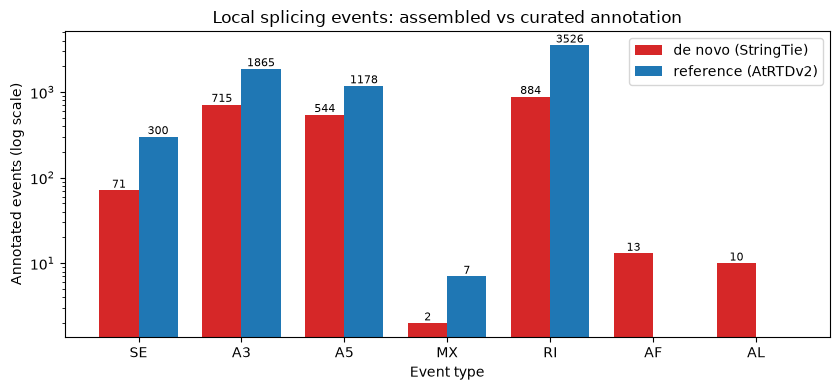

The assembly recovers roughly a quarter to a half of the events in each class, so AtRTDv2
is the better annotation wherever you have one — it simply gives you more to test.

Two details worth a moment:
  * AF and AL: the assembly finds them, the reference reports none. AtRTDv2's transcripts
    share annotated start/end structure, while assembled transcripts end wherever the reads
    ended, so first/last-exon variation appears that curation had smoothed away. Some is
    real biology, some is 5'/3' truncation in the reads. Treat de novo AF/AL with suspicion.
  * RI is the class the assembly recovers worst (884 vs 3,526) and still the class that
    carries the biology. Fewer events tested, same conclusion.


In [18]:
# Event inventory per annotation — the same `counts` computed in step 8.
inventory = pd.DataFrame(counts).loc[EVENT_TYPES]
inventory.columns = [ROUTE_LABEL[route] for route in inventory.columns]

denovo_column    = inventory[ROUTE_LABEL["denovo"]]
reference_column = inventory[ROUTE_LABEL["reference"]]
inventory["de novo / reference"] = denovo_column / reference_column.replace(0, np.nan)

display(inventory.style.format({"de novo / reference": "{:.2f}"}, na_rep="— (ref has none)"))

x = np.arange(len(EVENT_TYPES))
bar_width = 0.38

plt.figure(figsize=(8.5, 4))
for i, route in enumerate(ROUTES):
    heights = [counts[route][event_type] for event_type in EVENT_TYPES]
    bars = plt.bar(x + (i - 0.5) * bar_width, heights, bar_width,
                   label=ROUTE_LABEL[route], color=ROUTE_COLOUR[route])
    plt.bar_label(bars, fmt="%d", fontsize=8)

plt.xticks(x, EVENT_TYPES); plt.yscale("log")
plt.ylabel("Annotated events (log scale)"); plt.xlabel("Event type")
plt.title("Local splicing events: assembled vs curated annotation")
plt.legend(); plt.tight_layout(); plt.show()

print("The assembly recovers roughly a quarter to a half of the events in each class, so AtRTDv2\n"
      "is the better annotation wherever you have one — it simply gives you more to test.\n")
print("Two details worth a moment:\n"
      "  * AF and AL: the assembly finds them, the reference reports none. AtRTDv2's transcripts\n"
      "    share annotated start/end structure, while assembled transcripts end wherever the reads\n"
      "    ended, so first/last-exon variation appears that curation had smoothed away. Some is\n"
      "    real biology, some is 5'/3' truncation in the reads. Treat de novo AF/AL with suspicion.\n"
      "  * RI is the class the assembly recovers worst (884 vs 3,526) and still the class that\n"
      "    carries the biology. Fewer events tested, same conclusion.")


## 10. Summary

You ran a complete long-read alternative-splicing workflow **twice** — once against a transcriptome
built from the reads, once against the curated AtRTDv2 annotation. Genome alignment with
`minimap2 -ax splice` fed everything; `stringtie -L` + `--merge` + `gffread` built the assembly,
which we scored against AtRTDv2; **oarfish** quantified both transcript sets; SUPPA2 ran at the
isoform level (`-f ioi`) and on local events (`-f ioe`); and the winning retained intron was
confirmed by counting reads, which consults no annotation at all.

### The biological result

**There is more intron retention in the nucleus than in the cytoplasm.** The median retained-intron
event sits at **35 % in the nucleus and 3 % in the cytoplasm**, and of the introns whose retention
changes significantly, **244 of 250 point the nuclear way**. That is what the pathway predicts:
splicing happens in the nucleus and only finished transcripts are exported. The one-sidedness is what
tells us this is signal — noise would scatter events evenly.

Both annotations agree: **90 % (de novo) and 98 % (reference)** of significant changes lean nuclear,
and the intron we opened in IGV was found by the de novo route, in the reads.

**Four things worth carrying away**

* **Intron retention marks unfinished RNA (or not).** Fractionating cells is a way of *staging* RNA
  processing, not just locating it — retained introns are ambiguous in a whole-cell sample and
  expected in a nuclear one. This may lead to deeper conclusion with a proper analysis.
* **A known-answer control is what earns trust in a pipeline.** We predicted the direction before
  running anything. Had the events scattered evenly, that would have been a bug report, not a
  discovery.
* **You do not need a reference transcriptome — you need a transcript *set*, and long reads let you
  build one.** No annotation-free shortcut hides in the quantifier: `oarfish --genome-alignments`
  still requires `--annotation`. The assembly step is what buys the freedom.
* **The annotation changes what you can SEE far more than what you CONCLUDE.** The de novo route
  reached the same biology from a fifth as many events. Measure the cost, report it, then judge
  whether it moved your answer — here it did not.

Your own outputs are all under `results/`, split by route. `reference_outputs/` holds pre-computed
results from an older salmon-based run covering four conditions, so those numbers will not match.
